# Final Text Analysis — Indian Electric-Bus Market

This Google Colab notebook completes the approved lifecycle freeze, exploratory VADER sentiment analysis, consumer-topic Gensim LDA modelling, integrated tables/charts, and the final text-analysis report.

Governance:

- Authoritative inputs are lifecycle-v1 and the completed 120-row round-1 review.
- No original, interim, v2, frozen, or lifecycle-v1 dataset is overwritten.
- No synthetic data, web research, external API, or analytical-data download is used.
- Internet use is limited to package installation and the four declared NLTK resources.
- NueGo and Anthony Travels are operators and are never included in OEM-group comparisons.
- All outputs persist under Google Drive.


## 1. Install the pinned analysis environment

Run the next cell once in a fresh Colab runtime.


In [1]:
import subprocess, sys
PACKAGES = [
    "numpy==1.26.4", "scipy==1.12.0", "pandas==2.2.3", "nltk==3.9.1",
    "gensim==4.3.3", "scikit-learn==1.5.2", "matplotlib==3.9.2",
    "pyLDAvis==3.4.1", "openpyxl==3.1.5",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "--upgrade", *PACKAGES])
print("Installation complete. Restart the runtime now, then continue below.")


Installation complete. Restart the runtime now, then continue below.


> **STOP — restart the Colab runtime immediately after the installation cell.**
>
> Use **Runtime → Restart session**, then resume from the Drive-mount cell below. Do not rerun the installation cell in the restarted session.


## 2. Mount Drive and define persistent project paths


In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_ROOT = Path('/content/drive/MyDrive/EV_Bus_Project')
INPUT_V1 = PROJECT_ROOT / '01_data/processed/ev_bus_text_corpus_lifecycle_v1.csv'
INPUT_REVIEW = PROJECT_ROOT / '04_outputs/text/lifecycle/lifecycle_manual_validation_sample_completed.csv'
FROZEN_INPUT = PROJECT_ROOT / '01_data/processed/ev_bus_text_corpus_frozen.csv'
LIFECYCLE_FROZEN = PROJECT_ROOT / '01_data/processed/ev_bus_text_corpus_lifecycle_frozen.csv'
FINAL_DATA = PROJECT_ROOT / '01_data/processed/ev_bus_text_analysis_final.csv'
FINAL_DIR = PROJECT_ROOT / '04_outputs/text/final'
CHART_DIR = FINAL_DIR / 'charts'
FINAL_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

for required in [INPUT_V1, INPUT_REVIEW, FROZEN_INPUT]:
    if not required.exists():
        raise FileNotFoundError(f'Required project input is missing: {required}')
print('PROJECT_ROOT:', PROJECT_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/EV_Bus_Project


## 3. Download only the approved NLTK resources


In [3]:
import nltk
for resource in ['vader_lexicon', 'stopwords', 'wordnet', 'omw-1.4']:
    ok = nltk.download(resource, quiet=False)
    if not ok:
        raise RuntimeError(f'NLTK resource download failed: {resource}')
print('Approved NLTK resources are ready.')


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Approved NLTK resources are ready.


## 4. Environment and version checks


In [4]:
import hashlib, importlib.metadata as metadata, json, math, platform, random, re, warnings
from collections import Counter

import numpy as np
import pandas as pd
import scipy
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from gensim import corpora
from gensim.models import CoherenceModel, LdaModel, Phrases
from gensim.models.phrases import Phraser
import gensim
import sklearn

EXPECTED = {
 'numpy':'1.26.4','scipy':'1.12.0','pandas':'2.2.3','nltk':'3.9.1',
 'gensim':'4.3.3','scikit-learn':'1.5.2','matplotlib':'3.9.2',
 'pyLDAvis':'3.4.1','openpyxl':'3.1.5'
}
actual={name:metadata.version(name) for name in EXPECTED}
print('Python',platform.python_version())
print(pd.DataFrame({'expected':EXPECTED,'actual':actual}))
bad={k:(EXPECTED[k],actual[k]) for k in EXPECTED if actual[k]!=EXPECTED[k]}
if bad: raise RuntimeError(f'Version mismatch after restart: {bad}')

def df_to_md(frame):
    clean=frame.copy().fillna('')
    headers=[str(c) for c in clean.columns]
    rows=['| '+' | '.join(headers)+' |','|'+'|'.join(['---']*len(headers))+'|']
    for values in clean.astype(str).itertuples(index=False,name=None):
        rows.append('| '+' | '.join(v.replace('|','\|').replace('\n',' ') for v in values)+' |')
    return '\n'.join(rows)

SEED=42
random.seed(SEED); np.random.seed(SEED)
plt.rcParams.update({'figure.dpi':130,'savefig.dpi':200,'font.size':10,'axes.titleweight':'bold','axes.spines.top':False,'axes.spines.right':False})
SENTIMENT_COLORS={'Positive':'#2E8B57','Neutral':'#8A8F98','Negative':'#C44E52'}
LIFECYCLE_ORDER=['pre_adoption','procurement','post_use','general_unspecified']
SENTIMENT_ORDER=['Positive','Neutral','Negative']
print('Environment checks passed.')


<>:34: SyntaxWarning: invalid escape sequence '\|'
<>:34: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_4199/3670221991.py:34: SyntaxWarning: invalid escape sequence '\|'
  rows.append('| '+' | '.join(v.replace('|','\|').replace('\n',' ') for v in values)+' |')


Python 3.12.13
             expected  actual
numpy          1.26.4  1.26.4
scipy          1.12.0  1.12.0
pandas          2.2.3   2.2.3
nltk            3.9.1   3.9.1
gensim          4.3.3   4.3.3
scikit-learn    1.5.2   1.5.2
matplotlib      3.9.2   3.9.2
pyLDAvis        3.4.1   3.4.1
openpyxl        3.1.5   3.1.5
Environment checks passed.


## 5. Load and validate authoritative inputs

This cell records protected-input hashes and stops on identifier, schema, Boolean, or controlled-category inconsistencies.


In [5]:
def sha256(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        for chunk in iter(lambda:f.read(1024*1024),b''): h.update(chunk)
    return h.hexdigest()

def as_bool(series):
    def parse(x):
        if isinstance(x,(bool,np.bool_)): return bool(x)
        value=str(x).strip().lower()
        if value in {'true','1','yes'}: return True
        if value in {'false','0','no'}: return False
        raise ValueError(f'Unparseable Boolean value in {series.name}: {x!r}')
    return series.map(parse).astype(bool)

hashes_before={str(p.relative_to(PROJECT_ROOT)):sha256(p) for p in [INPUT_V1,INPUT_REVIEW,FROZEN_INPUT]}
v1=pd.read_csv(INPUT_V1)
review=pd.read_csv(INPUT_REVIEW,keep_default_na=False)
frozen=pd.read_csv(FROZEN_INPUT)

assert len(v1)==548 and v1.comment_id.notna().all() and v1.comment_id.is_unique
assert len(review)==120 and review.comment_id.ne('').all() and review.comment_id.is_unique
assert set(review.comment_id).issubset(set(v1.comment_id))
assert len(frozen)==548 and frozen.comment_id.is_unique
assert set(frozen.columns).issubset(v1.columns)
for c in frozen.columns: pd.testing.assert_series_equal(v1[c],frozen[c],check_names=False)
assert set(v1.lifecycle_stage_auto.dropna())<=set(LIFECYCLE_ORDER)
assert set(v1.lifecycle_confidence.dropna())<={'high','medium','low'}
assert set(review.human_lifecycle_stage)<=set(LIFECYCLE_ORDER)
assert set(review.human_confidence)<={'high','medium','low'}
for c in ['consumer_sentiment_eligible_final','consumer_topic_eligible_final','lifecycle_ambiguous','lifecycle_manual_review_required']:
    as_bool(v1[c])
print('Authoritative inputs validated. Hashes:',json.dumps(hashes_before,indent=2))


Authoritative inputs validated. Hashes: {
  "01_data/processed/ev_bus_text_corpus_lifecycle_v1.csv": "3aecc5393cd3dd702bcf63fe66ecb084322163aa1a25948e606283ba89517f11",
  "04_outputs/text/lifecycle/lifecycle_manual_validation_sample_completed.csv": "4c7a0dfc04de294b9d39ee79548bc31fa2aca9e7322ec003d9b1b4252a3b63b3",
  "01_data/processed/ev_bus_text_corpus_frozen.csv": "cb367213ecfe96295dcb83beb615799d74882e65240cc6bc1e8901e26fa0be69"
}


## 6. Freeze final lifecycle labels

All 120 reviewed rows use human labels. Unreviewed high/medium labels are retained. Unreviewed low-confidence rows are conservatively assigned `general_unspecified`, reflecting the 19.7% low-confidence agreement in the deliberately risk-enriched validation sample.


In [6]:
human=review[['comment_id','human_lifecycle_stage','human_confidence','human_evidence_note']].copy()
life=v1.merge(human,on='comment_id',how='left',validate='one_to_one',indicator=True)
assert len(life)==548 and life.raw_text.equals(v1.raw_text)
reviewed=life['_merge'].eq('both')
life['lifecycle_human_reviewed']=reviewed
life['lifecycle_stage_final']=life['lifecycle_stage_auto']
life['lifecycle_confidence_final']=life['lifecycle_confidence']
life['lifecycle_label_source']=''
life['lifecycle_final_note']=''

life.loc[reviewed,'lifecycle_stage_final']=life.loc[reviewed,'human_lifecycle_stage']
life.loc[reviewed,'lifecycle_confidence_final']=life.loc[reviewed,'human_confidence']
life.loc[reviewed,'lifecycle_label_source']='human_review_round1'
life.loc[reviewed,'lifecycle_final_note']=life.loc[reviewed,'human_evidence_note']

unreviewed=~reviewed
high=unreviewed & life.lifecycle_confidence.eq('high')
medium=unreviewed & life.lifecycle_confidence.eq('medium')
low=unreviewed & life.lifecycle_confidence.eq('low')
life.loc[high,'lifecycle_label_source']='automated_high_confidence'
life.loc[medium,'lifecycle_label_source']='automated_medium_confidence'
life.loc[low,'lifecycle_stage_final']='general_unspecified'
life.loc[low,'lifecycle_confidence_final']='low'
life.loc[low,'lifecycle_label_source']='conservative_unspecified_low_confidence'
life.loc[low,'lifecycle_final_note']=life.loc[low,'lifecycle_stage_auto'].map(
 lambda x: f'Unreviewed low-confidence automated label ({x}) not accepted because round-1 low-confidence agreement was 19.7%; conservatively set to general_unspecified.')
life=life.drop(columns=['_merge'])
assert reviewed.sum()==120 and low.sum()==41
assert set(life.lifecycle_stage_final)<=set(LIFECYCLE_ORDER)
assert life.loc[low,'lifecycle_stage_final'].eq('general_unspecified').all()
life.to_csv(LIFECYCLE_FROZEN,index=False)

def distribution(data,col,order=None):
    count=data[col].value_counts().reindex(order,fill_value=0) if order else data[col].value_counts()
    z=count.rename_axis(col).reset_index(name='row_count'); z['percent']=100*z.row_count/len(data); z['total_n']=len(data); return z

life_dist=distribution(life,'lifecycle_stage_final',LIFECYCLE_ORDER)
source_dist=distribution(life,'lifecycle_label_source')
life_dist.to_csv(FINAL_DIR/'lifecycle_final_distribution.csv',index=False)
source_dist.to_csv(FINAL_DIR/'lifecycle_label_source_distribution.csv',index=False)

freeze_report=f'''# Final Lifecycle Freeze Report

- Lifecycle-v1 rows retained: **{len(life)}**; unique IDs: **{life.comment_id.nunique()}**.
- Round-1 human labels applied: **{int(reviewed.sum())}**.
- Round-1 sample was risk-enriched rather than random; its accuracy is not an unbiased corpus-wide estimate.
- Overall agreement: **55.8%**; high-confidence: **92.0%**; medium-confidence: **94.1%**; low-confidence: **19.7%**.
- Main failure: automated `general_unspecified` under-classified specific lifecycle stages, especially `pre_adoption`.
- All **{int(low.sum())}** remaining unreviewed low-confidence rows were conservatively retained as `general_unspecified`.
- The 87-row round-2 review was generated but not manually completed because of the submission timeline.
- High/medium unreviewed labels remain automated and must be distinguished from round-1 human-reviewed labels using `lifecycle_label_source`.
- No upstream dataset was overwritten and raw text was unchanged.
'''
(FINAL_DIR/'lifecycle_freeze_report.md').write_text(freeze_report,encoding='utf-8')
display(life_dist); display(source_dist)


,lifecycle_stage_final,row_count,percent,total_n
0,pre_adoption,53,9.671533,548
1,procurement,20,3.649635,548
2,post_use,74,13.503650,548
3,general_unspecified,401,73.175182,548


,lifecycle_label_source,row_count,percent,total_n
0,automated_medium_confidence,365,66.605839,548
1,human_review_round1,120,21.897810,548
2,conservative_unspecified_low_confidence,41,7.481752,548
3,automated_high_confidence,22,4.014599,548


## 7. VADER sentiment analysis

VADER is applied only where `consumer_sentiment_eligible_final == True`, using `sentiment_text`. Rows outside scope remain in the dataset with blank sentiment outputs.


In [7]:
df=life.copy()
sent_scope=as_bool(df.consumer_sentiment_eligible_final)
assert df.loc[sent_scope,'speaker_role_final'].isin(['media_or_research','creator_or_brand']).sum()==0
sia=SentimentIntensityAnalyzer()
score_cols=['vader_positive','vader_neutral','vader_negative','vader_compound']
for c in score_cols: df[c]=np.nan
df['sentiment_label']=pd.NA
scores=df.loc[sent_scope,'sentiment_text'].fillna('').map(sia.polarity_scores)
score_frame=pd.DataFrame(scores.tolist(),index=scores.index).rename(columns={'pos':'vader_positive','neu':'vader_neutral','neg':'vader_negative','compound':'vader_compound'})
df.loc[sent_scope,score_cols]=score_frame[score_cols]
df.loc[sent_scope,'sentiment_label']=np.select(
 [df.loc[sent_scope,'vader_compound'].ge(0.05),df.loc[sent_scope,'vader_compound'].le(-0.05)],
 ['Positive','Negative'],default='Neutral')
assert df.loc[~sent_scope,score_cols].isna().all().all() and df.loc[~sent_scope,'sentiment_label'].isna().all()

def sentiment_summary(data,group_cols=None):
    group_cols=[] if group_cols is None else list(group_cols)
    rows=[]
    groups=[((),data)] if not group_cols else data.groupby(group_cols,dropna=False,observed=False)
    for keys,g in groups:
        if not isinstance(keys,tuple): keys=(keys,)
        row=dict(zip(group_cols,keys)); n=len(g); counts=g.sentiment_label.value_counts()
        row.update({'eligible_n':n,'positive_count':int(counts.get('Positive',0)),'positive_pct':100*counts.get('Positive',0)/n if n else np.nan,
                    'neutral_count':int(counts.get('Neutral',0)),'neutral_pct':100*counts.get('Neutral',0)/n if n else np.nan,
                    'negative_count':int(counts.get('Negative',0)),'negative_pct':100*counts.get('Negative',0)/n if n else np.nan,
                    'mean_compound':g.vader_compound.mean(),'median_compound':g.vader_compound.median(),'small_sample_flag':n<15})
        rows.append(row)
    return pd.DataFrame(rows)

eligible=df.loc[sent_scope].copy()
overall=sentiment_summary(eligible)
by_lifecycle=sentiment_summary(eligible,['lifecycle_stage_final']).set_index('lifecycle_stage_final').reindex(LIFECYCLE_ORDER).reset_index()

oem_scope=eligible.entity_type.eq('OEM') & eligible.oem_group.isin(['legacy','new_age']) & eligible.speaker_role_final.eq('audience_user')
by_oem=sentiment_summary(eligible.loc[oem_scope],['oem_group'])
entities=['Tata Motors','JBM Auto','Olectra Greentech','EKA Mobility','PMI Electro','Switch Mobility','NueGo']
by_entity=sentiment_summary(eligible.loc[eligible.entity_name_canonical.isin(entities)],['entity_name_canonical','entity_type'])
by_entity['comparison_role']=np.where(by_entity.entity_type.eq('Operator'),'Operator (not an OEM)','OEM')
by_platform=sentiment_summary(eligible,['platform_canonical'])
by_provenance=sentiment_summary(eligible,['provenance'])

for table,name in [(overall,'sentiment_overall.csv'),(by_lifecycle,'sentiment_by_lifecycle.csv'),(by_oem,'sentiment_by_oem_group.csv'),
                   (by_entity,'sentiment_by_entity.csv'),(by_platform,'sentiment_by_platform.csv'),(by_provenance,'sentiment_by_provenance.csv')]:
    table.to_csv(FINAL_DIR/name,index=False)
display(overall); display(by_lifecycle); display(by_oem); display(by_entity)


,eligible_n,positive_count,positive_pct,neutral_count,neutral_pct,negative_count,negative_pct,mean_compound,median_compound,small_sample_flag
0,438,225,51.369863,128,29.223744,85,19.406393,0.178695,0.0772,False


,lifecycle_stage_final,eligible_n,positive_count,positive_pct,neutral_count,neutral_pct,negative_count,negative_pct,mean_compound,median_compound,small_sample_flag
0,pre_adoption,48,24,50.000000,13,27.083333,11,22.916667,0.193275,0.1072,False
1,procurement,19,13,68.421053,2,10.526316,4,21.052632,0.287526,0.3182,False
2,post_use,49,24,48.979592,8,16.326531,17,34.693878,0.084784,0.0000,False
3,general_unspecified,322,164,50.931677,105,32.608696,53,16.459627,0.184390,0.0772,False


,oem_group,eligible_n,positive_count,positive_pct,neutral_count,neutral_pct,negative_count,negative_pct,mean_compound,median_compound,small_sample_flag
0,legacy,21,14,66.666667,5,23.809524,2,9.523810,0.359300,0.5106,False
1,new_age,27,16,59.259259,7,25.925926,4,14.814815,0.264326,0.3597,False


,entity_name_canonical,entity_type,eligible_n,positive_count,positive_pct,neutral_count,neutral_pct,negative_count,negative_pct,mean_compound,median_compound,small_sample_flag,comparison_role
0,EKA Mobility,OEM,7,5,71.428571,1,14.285714,1,14.285714,0.495500,0.74250,True,OEM
1,JBM Auto,OEM,11,7,63.636364,2,18.181818,2,18.181818,0.265064,0.30080,True,OEM
2,NueGo,Operator,38,20,52.631579,4,10.526316,14,36.842105,0.068474,0.13270,False,Operator (not an OEM)
3,Olectra Greentech,OEM,7,4,57.142857,0,0.000000,3,42.857143,0.097286,0.42150,True,OEM
4,PMI Electro,OEM,6,4,66.666667,2,33.333333,0,0.000000,0.241633,0.31565,True,OEM
5,Switch Mobility,OEM,7,3,42.857143,4,57.142857,0,0.000000,0.219643,0.00000,True,OEM
6,Tata Motors,OEM,10,7,70.000000,3,30.000000,0,0.000000,0.462960,0.56465,True,OEM


## 8. Sentiment audit sample (non-blocking)

The deterministic ~40-row sample covers sentiment labels, lifecycle stages, legacy/new-age OEMs, NueGo, and observed Hinglish/code-switching where available. Human fields are intentionally blank; analysis continues without waiting for review.


In [8]:
rng=np.random.default_rng(SEED); picked=[]; reasons={}
def add_sample(mask,reason,n):
    candidates=[i for i in eligible.index[mask] if i not in picked]
    candidates=sorted(candidates,key=lambda i:str(df.at[i,'comment_id']))
    if len(candidates)>n: candidates=sorted(rng.choice(candidates,size=n,replace=False).tolist(),key=lambda i:str(df.at[i,'comment_id']))
    for i in candidates:
        if len(picked)>=40: break
        picked.append(i); reasons.setdefault(i,[]).append(reason)

for label in SENTIMENT_ORDER: add_sample(eligible.sentiment_label.eq(label),f'sentiment_{label.lower()}',8)
for stage in LIFECYCLE_ORDER: add_sample(eligible.lifecycle_stage_final.eq(stage),f'lifecycle_{stage}',3)
add_sample(eligible.oem_group.eq('legacy'),'legacy_oem',4); add_sample(eligible.oem_group.eq('new_age'),'new_age_oem',4)
add_sample(eligible.entity_name_canonical.eq('NueGo'),'operator_nuego',4)
add_sample(eligible.hinglish_terms_detected.fillna('').str.strip().ne(''),'hinglish_or_code_switched',6)
remaining=[i for i in eligible.index if i not in picked]
for i in sorted(remaining,key=lambda i:str(df.at[i,'comment_id'])):
    if len(picked)>=40: break
    picked.append(i); reasons.setdefault(i,[]).append('deterministic_fill')

audit=df.loc[picked,['comment_id','raw_text','sentiment_text','entity_name_canonical','entity_type','oem_group','platform_canonical','provenance','lifecycle_stage_final','vader_compound','sentiment_label','hinglish_terms_detected']].copy()
audit['sentiment_sampling_reason']=['; '.join(reasons[i]) for i in picked]
audit['human_sentiment_label']=''; audit['human_sentiment_note']=''
audit.to_csv(FINAL_DIR/'sentiment_manual_check_sample.csv',index=False)
assert len(audit)==40 and audit.comment_id.is_unique and audit[['human_sentiment_label','human_sentiment_note']].eq('').all().all()
display(audit.groupby(['sentiment_label','lifecycle_stage_final']).size().rename('n').reset_index())


,sentiment_label,lifecycle_stage_final,n
0,Negative,general_unspecified,5
1,Negative,post_use,2
2,Negative,pre_adoption,2
3,Neutral,general_unspecified,7
4,Neutral,pre_adoption,4
5,Neutral,procurement,1
6,Positive,general_unspecified,7
7,Positive,post_use,4
8,Positive,pre_adoption,5
9,Positive,procurement,3


## 9. Publication-ready sentiment and lifecycle charts

Charts show descriptive sample evidence only. N values are printed in labels or captions; no statistical-significance claim is made.


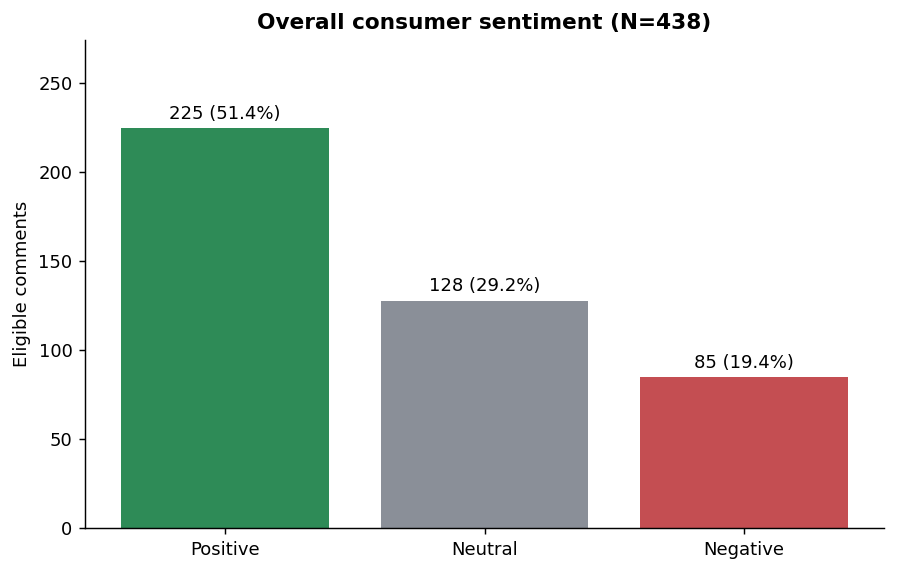

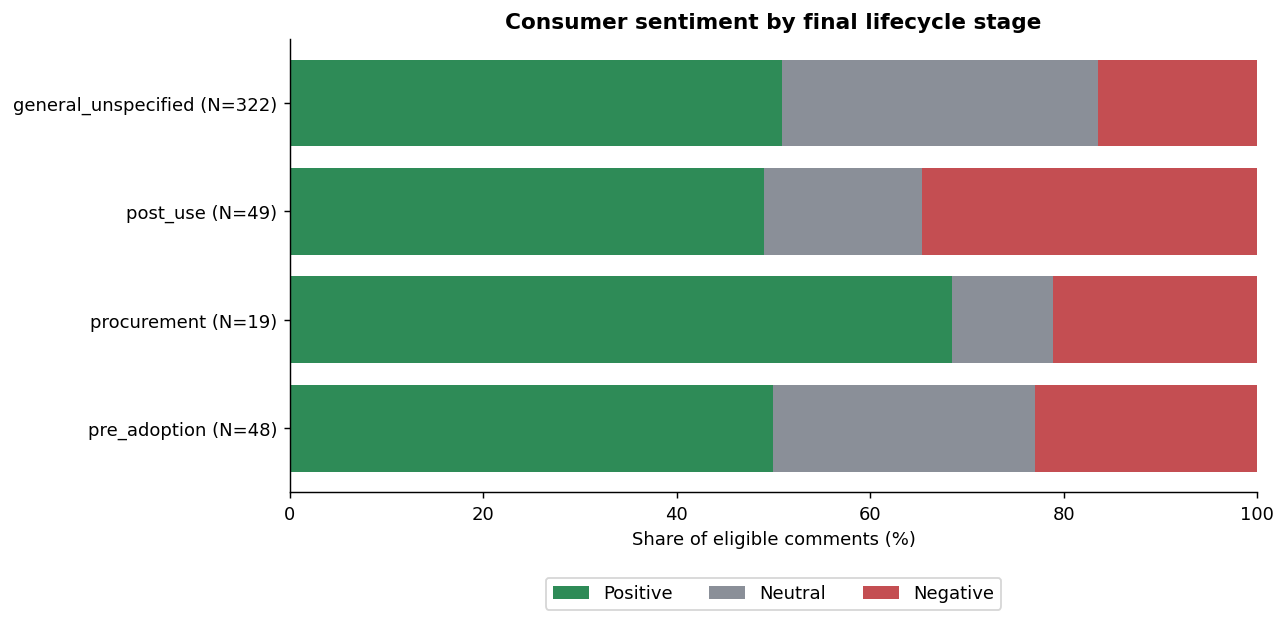

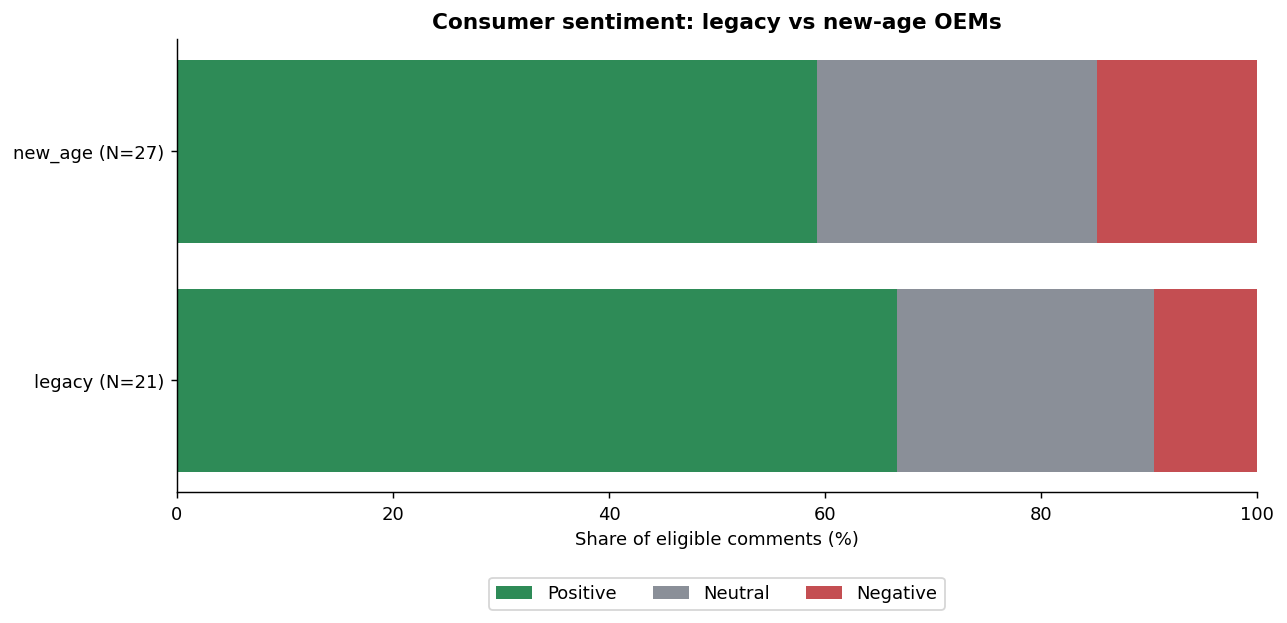

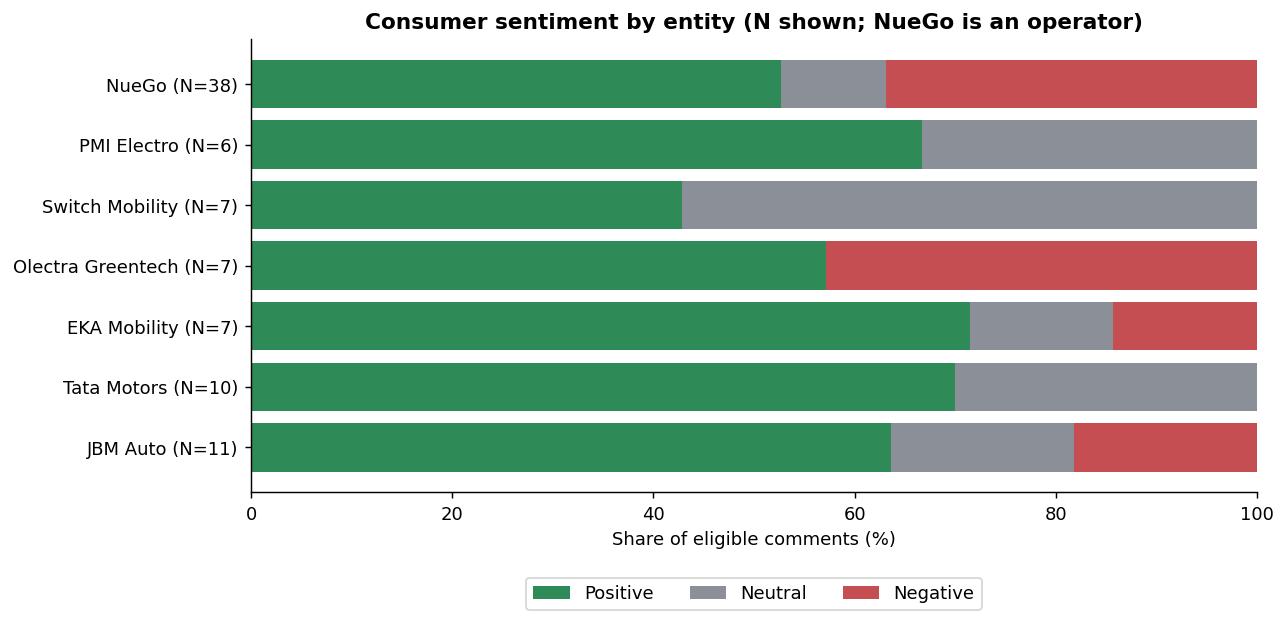

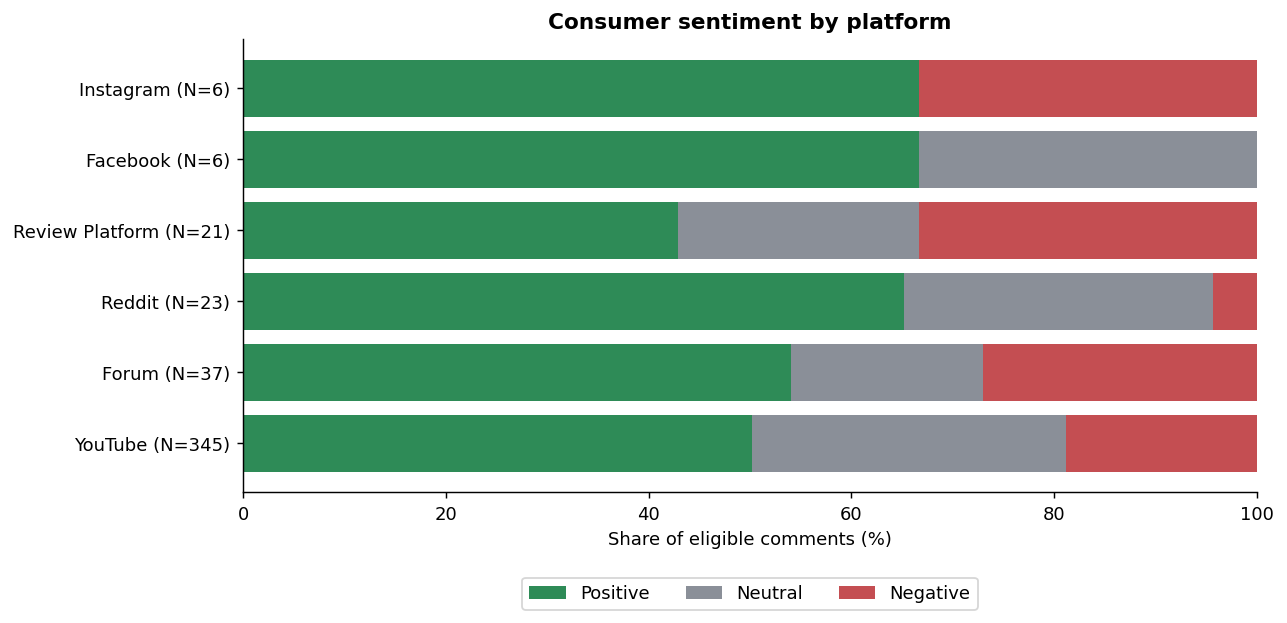

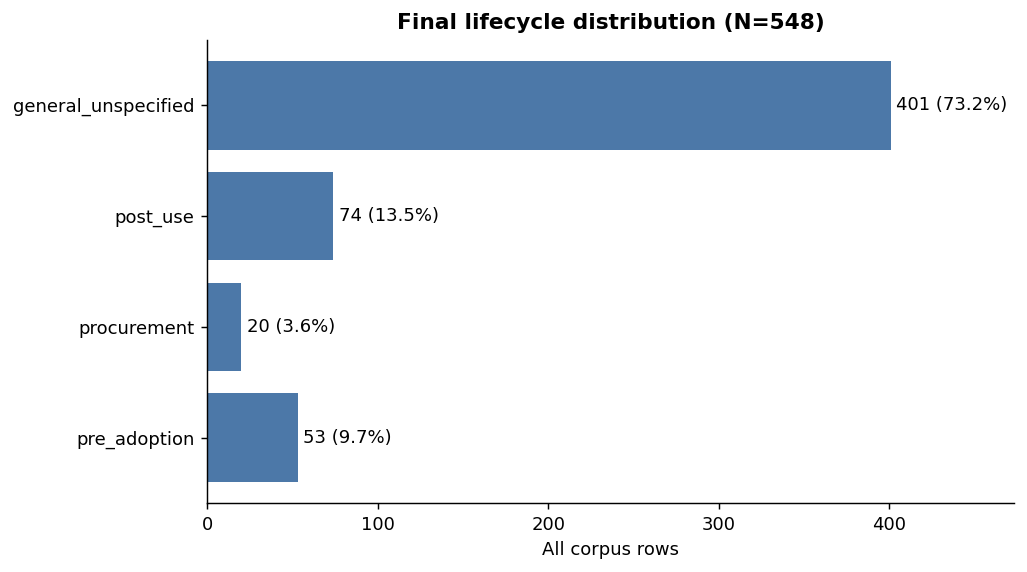

In [9]:
def savefig(name):
    plt.tight_layout(); plt.savefig(CHART_DIR/name,bbox_inches='tight',facecolor='white'); plt.show(); plt.close()

# Overall sentiment
fig,ax=plt.subplots(figsize=(7,4.5)); vals=[int(overall.iloc[0][f'{x.lower()}_count']) for x in SENTIMENT_ORDER]
bars=ax.bar(SENTIMENT_ORDER,vals,color=[SENTIMENT_COLORS[x] for x in SENTIMENT_ORDER]); ax.set_ylim(0,max(vals)*1.22); ax.set_ylabel('Eligible comments')
ax.set_title(f'Overall consumer sentiment (N={len(eligible)})'); ax.bar_label(bars,labels=[f'{v} ({100*v/len(eligible):.1f}%)' for v in vals],padding=3); savefig('sentiment_overall.png')

def stacked100(table,label_col,title,name):
    z=table.set_index(label_col); fig,ax=plt.subplots(figsize=(10,5)); left=np.zeros(len(z)); x=np.arange(len(z))
    for s in SENTIMENT_ORDER:
        vals=z[f'{s.lower()}_pct'].fillna(0).to_numpy(); ax.barh(x,vals,left=left,label=s,color=SENTIMENT_COLORS[s]); left+=vals
    ax.set_yticks(x,labels=[f'{idx} (N={int(n)})' for idx,n in zip(z.index,z.eligible_n)]); ax.set_xlim(0,100); ax.set_xlabel('Share of eligible comments (%)'); ax.set_title(title); ax.legend(ncol=3,loc='lower center',bbox_to_anchor=(0.5,-0.28)); savefig(name)

stacked100(by_lifecycle,'lifecycle_stage_final','Consumer sentiment by final lifecycle stage','sentiment_by_lifecycle_100pct.png')
stacked100(by_oem,'oem_group','Consumer sentiment: legacy vs new-age OEMs','sentiment_legacy_vs_new_age.png')
stacked100(by_entity.sort_values(['comparison_role','eligible_n'],ascending=[True,False]),'entity_name_canonical','Consumer sentiment by entity (N shown; NueGo is an operator)','sentiment_by_entity.png')
stacked100(by_platform.sort_values('eligible_n',ascending=False),'platform_canonical','Consumer sentiment by platform','sentiment_by_platform.png')

fig,ax=plt.subplots(figsize=(8,4.5)); z=life_dist.set_index('lifecycle_stage_final').loc[LIFECYCLE_ORDER]; bars=ax.barh(z.index,z.row_count,color='#4C78A8'); ax.set_xlim(0,z.row_count.max()*1.18); ax.set_xlabel('All corpus rows'); ax.set_title('Final lifecycle distribution (N=548)'); ax.bar_label(bars,labels=[f'{n} ({p:.1f}%)' for n,p in zip(z.row_count,z.percent)],padding=3); savefig('lifecycle_distribution_final.png')


## 10. Consumer-topic corpus and reproducible LDA evaluation

Primary scope requires the frozen consumer-topic flag, audience-user role, usable `topic_model_text` with at least three tokens, and either no duplicate cluster or selection as the duplicate representative. Frequent interpretable bigrams are learned only within this scope. Dictionary filtering removes terms appearing in fewer than 3 documents or more than 60% of documents while retaining domain tokens when present. Models K=2…8 use seed 42.


In [10]:
topic_scope=as_bool(df.consumer_topic_eligible_final)
tokens=df.topic_model_text.fillna('').map(lambda x:[t for t in str(x).split() if t.strip()])
dup_ok=df.near_duplicate_cluster_id.fillna('').astype(str).str.strip().eq('') | as_bool(df.near_duplicate_representative)
role_ok=df.speaker_role_final.eq('audience_user')
usable=topic_scope & tokens.map(len).ge(3) & dup_ok & role_ok
assert df.loc[usable,'speaker_role_final'].eq('audience_user').all()

raw_docs=tokens.loc[usable].tolist()
phrase_model=Phrases(raw_docs,min_count=5,threshold=12.0,delimiter='_')
bigram=Phraser(phrase_model)
docs=[bigram[d] for d in raw_docs]
dictionary=corpora.Dictionary(docs)
DOMAIN_TERMS={'electric','bus','buses','battery','charging','charger','range','tender','contract','operator','driver','service','route','ticket','refund','maintenance','diesel','cng','ev'}
domain_ids={dictionary.token2id[t] for t in DOMAIN_TERMS if t in dictionary.token2id}
dictionary.filter_extremes(no_below=3,no_above=0.60,keep_tokens=[dictionary[i] for i in domain_ids])
corpus=[dictionary.doc2bow(d) for d in docs]
nonempty=np.array([len(x)>0 for x in corpus])
if not nonempty.all():
    valid_indices=np.array(df.index[usable])[nonempty]; docs=[d for d,k in zip(docs,nonempty) if k]; corpus=[c for c in corpus if c]
else: valid_indices=np.array(df.index[usable])
assert len(corpus)>0 and len(dictionary)>0
print(f'Topic documents: {len(corpus)}; vocabulary: {len(dictionary)}; learned bigrams: {sum("_" in t for t in dictionary.token2id)}')

models={}; eval_rows=[]; top_sets={}
for k in range(2,9):
    model=LdaModel(corpus=corpus,id2word=dictionary,num_topics=k,random_state=SEED,passes=15,iterations=150,alpha='auto',eta='auto',minimum_probability=0.0,eval_every=None)
    coherence=CoherenceModel(model=model,texts=docs,dictionary=dictionary,coherence='c_v',processes=1).get_coherence()
    perplexity=model.log_perplexity(corpus)
    sets=[set(w for w,_ in model.show_topic(i,topn=12)) for i in range(k)]
    overlaps=[len(sets[i]&sets[j])/len(sets[i]|sets[j]) for i in range(k) for j in range(i+1,k)]
    mean_overlap=float(np.mean(overlaps)) if overlaps else 0.0; max_overlap=float(np.max(overlaps)) if overlaps else 0.0
    warning='high_overlap' if max_overlap>=0.50 else ('moderate_overlap' if max_overlap>=0.35 else 'low_overlap')
    models[k]=model; top_sets[k]=sets
    eval_rows.append({'topic_count_k':k,'coherence_cv':coherence,'log_perplexity':perplexity,'mean_top_term_jaccard':mean_overlap,'max_top_term_jaccard':max_overlap,'qualitative_overlap_warning':warning})
coherence_df=pd.DataFrame(eval_rows)
best=coherence_df.coherence_cv.max(); candidates=coherence_df[coherence_df.coherence_cv.ge(best-0.01)].copy()
candidates['selection_score']=candidates.coherence_cv-0.10*candidates.mean_top_term_jaccard-0.03*(candidates.topic_count_k-2)/6
selected_k=int(candidates.sort_values(['selection_score','topic_count_k'],ascending=[False,True]).iloc[0].topic_count_k)
selected_model=models[selected_k]; selected_coherence=float(coherence_df.loc[coherence_df.topic_count_k.eq(selected_k),'coherence_cv'].iloc[0])
coherence_df['selected_model']=coherence_df.topic_count_k.eq(selected_k)
coherence_df['selection_note']=np.where(coherence_df.selected_model,'Selected using coherence within 0.01 of best, lower overlap, interpretability/parsimony; not coherence alone','')
coherence_df.to_csv(FINAL_DIR/'topic_coherence.csv',index=False)
display(coherence_df)


Topic documents: 411; vocabulary: 541; learned bigrams: 8


,topic_count_k,coherence_cv,log_perplexity,mean_top_term_jaccard,max_top_term_jaccard,qualitative_overlap_warning,selected_model,selection_note
0,2,0.302422,-6.076133,0.333333,0.333333,low_overlap,False,
1,3,0.322031,-6.084005,0.225397,0.333333,low_overlap,False,
2,4,0.326710,-6.154085,0.181994,0.333333,low_overlap,False,
3,5,0.335450,-6.199465,0.146508,0.263158,low_overlap,False,
4,6,0.334303,-6.251967,0.120211,0.200000,low_overlap,False,
5,7,0.340562,-6.305892,0.109184,0.263158,low_overlap,False,
6,8,0.355843,-6.374706,0.141029,0.500000,high_overlap,True,"Selected using coherence within 0.01 of best, ..."


## 11. Selected topics, labels, assignments, and cross-tabs

Labels are provisional descriptions based on top terms and representative comments. `final_topic_label` initially equals the provisional label and explicitly requires team sign-off.


In [11]:
topic_terms={i:[w for w,_ in selected_model.show_topic(i,topn=12)] for i in range(selected_k)}
def provisional_label(i):
    terms=topic_terms[i]
    return f"Topic {i}: " + ' / '.join(t.replace('_',' ') for t in terms[:3])

labels={i:provisional_label(i) for i in range(selected_k)}
doc_topics=[]
for idx,bow in zip(valid_indices,corpus):
    probs=selected_model.get_document_topics(bow,minimum_probability=0.0); tid,prob=max(probs,key=lambda x:x[1])
    doc_topics.append({'comment_id':df.at[idx,'comment_id'],'dominant_topic_id':int(tid),'dominant_topic_probability':float(prob)})
assignments=pd.DataFrame(doc_topics)
assigned=df.merge(assignments,on='comment_id',how='inner',validate='one_to_one')
assigned['provisional_topic_label']=assigned.dominant_topic_id.map(labels)
assigned['final_topic_label']=assigned.provisional_topic_label
assigned['analysis_group']=np.select(
 [assigned.entity_type.eq('Operator'),assigned.entity_type.eq('OEM')&assigned.oem_group.eq('legacy'),assigned.entity_type.eq('OEM')&assigned.oem_group.eq('new_age')],
 ['Operator','legacy','new_age'],default='General/Industry')

reps=[]
for tid,g in assigned.groupby('dominant_topic_id'):
    for rank,(_,r) in enumerate(g.nlargest(5,'dominant_topic_probability').iterrows(),1):
        reps.append({'topic_id':int(tid),'provisional_topic_label':labels[int(tid)],'representative_rank':rank,'comment_id':r.comment_id,
                     'dominant_topic_probability':r.dominant_topic_probability,'raw_text':r.raw_text,'sentiment_label':r.sentiment_label,
                     'vader_compound':r.vader_compound,'lifecycle_stage_final':r.lifecycle_stage_final,'entity_name_canonical':r.entity_name_canonical})
reps=pd.DataFrame(reps); reps.to_csv(FINAL_DIR/'topic_representative_comments.csv',index=False)

summary=[]
for tid,g in assigned.groupby('dominant_topic_id'):
    terms=topic_terms[int(tid)]; top='; '.join(terms); n=len(g)
    summary.append({'topic_id':int(tid),'provisional_topic_label':labels[int(tid)],'final_topic_label':labels[int(tid)],'team_signoff_status':'REQUIRES_TEAM_SIGNOFF',
                    'top_12_terms':top,'document_count':n,'prevalence_pct':100*n/len(assigned),'average_sentiment_compound':g.vader_compound.mean(),
                    'representative_comment_ids':'; '.join(reps.loc[reps.topic_id.eq(tid),'comment_id'].head(5))})
topic_summary=pd.DataFrame(summary).sort_values('topic_id'); topic_summary.to_csv(FINAL_DIR/'topic_model_summary.csv',index=False)

def topic_crosstab(col,dimension_name):
    z=pd.crosstab(assigned.dominant_topic_id,assigned[col],normalize='index').mul(100).stack().rename('percent').reset_index().rename(columns={col:'group_value'})
    counts=pd.crosstab(assigned.dominant_topic_id,assigned[col]).stack().rename('row_count').reset_index().rename(columns={col:'group_value'})
    z=z.merge(counts,on=['dominant_topic_id','group_value']); z.insert(1,'dimension',dimension_name); return z

topic_sent=topic_crosstab('sentiment_label','sentiment_label'); topic_sent.to_csv(FINAL_DIR/'topic_by_sentiment.csv',index=False)
topic_life=topic_crosstab('lifecycle_stage_final','lifecycle_stage_final'); topic_life.to_csv(FINAL_DIR/'topic_by_lifecycle.csv',index=False)
topic_oem=pd.concat([topic_crosstab('analysis_group','analysis_group'),topic_crosstab('oem_group','oem_group'),topic_crosstab('entity_name_canonical','entity_name_canonical')],ignore_index=True)
topic_oem.to_csv(FINAL_DIR/'topic_by_oem_group.csv',index=False)

assignments.merge(assigned[['comment_id','provisional_topic_label','final_topic_label']],on='comment_id',validate='one_to_one').to_csv(FINAL_DIR/'document_topic_assignments.csv',index=False)
labels_review=topic_summary[['topic_id','top_12_terms','provisional_topic_label','final_topic_label','team_signoff_status']].copy()
labels_review['team_approved_label']=''; labels_review['team_review_note']=''; labels_review.to_csv(FINAL_DIR/'topic_labels_for_review.csv',index=False)
display(topic_summary); display(reps.head(10))


,topic_id,provisional_topic_label,final_topic_label,team_signoff_status,top_12_terms,document_count,prevalence_pct,average_sentiment_compound,representative_comment_ids
0,0,Topic 0: buses / like / india,Topic 0: buses / like / india,REQUIRES_TEAM_SIGNOFF,buses; like; india; time; battery; years; chin...,60,14.598540,0.130485,c_03c4d25dec2605b7f00f; c_d5a85b1b26251b961f4d...
1,1,Topic 1: hai / bus / ki,Topic 1: hai / bus / ki,REQUIRES_TEAM_SIGNOFF,hai; bus; ki; buses; ke; ko; bhi; battery; del...,61,14.841849,0.161939,c_fb1100afdebffcfa4c90; c_f92d7896fa0ca24d3fec...
2,2,Topic 2: battery / bus / batteries,Topic 2: battery / bus / batteries,REQUIRES_TEAM_SIGNOFF,battery; bus; batteries; much; sodium_ion; kwh...,43,10.462287,0.142595,c_735f6b0eb726ae45cc08; c_a1a567704543e011482c...
3,3,Topic 3: india / bus / buses,Topic 3: india / bus / buses,REQUIRES_TEAM_SIGNOFF,india; bus; buses; well; money; mobility; like...,52,12.652068,0.202094,c_da2c50c84faf31c1da9a; c_bc86d6fbf3fada0f1c7c...
4,4,Topic 4: bus / buses / battery,Topic 4: bus / buses / battery,REQUIRES_TEAM_SIGNOFF,bus; buses; battery; indian; company; ev; elec...,62,15.085158,0.246402,c_db7a80da68ee3b5a274a; c_bc8b009f3181b685763e...
5,5,Topic 5: china / bus / hai,Topic 5: china / bus / hai,REQUIRES_TEAM_SIGNOFF,china; bus; hai; jbm; tender; battery; se; ple...,47,11.435523,0.255128,c_d126f8b6da5975bad834; c_9881cc4f672184a409de...
6,6,Topic 6: olectra / india / bus,Topic 6: olectra / india / bus,REQUIRES_TEAM_SIGNOFF,olectra; india; bus; battery; indian; ac; buse...,42,10.218978,0.138221,c_8d3f86eea5da5c02a0f0; c_d76861d25db7f2833670...
7,7,Topic 7: india / electric / china,Topic 7: india / electric / china,REQUIRES_TEAM_SIGNOFF,india; electric; china; model; government; lon...,44,10.705596,0.159416,c_2331c6e329446b79e0a5; c_70facd39f477ac8f0a2b...


,topic_id,provisional_topic_label,representative_rank,comment_id,dominant_topic_probability,raw_text,sentiment_label,vader_compound,lifecycle_stage_final,entity_name_canonical
0,0,Topic 0: buses / like / india,1,c_03c4d25dec2605b7f00f,0.991905,"Countries like Singapore, Dubai, and many Euro...",Positive,0.9671,post_use,General/Industry
1,0,Topic 0: buses / like / india,2,c_d5a85b1b26251b961f4d,0.991905,Why do you raise suspecisions about what may h...,Positive,0.8091,general_unspecified,General/Industry
2,0,Topic 0: buses / like / india,3,c_0e1094360c0488669630,0.977981,free buses=people using more buses=less traffi...,Positive,0.6486,general_unspecified,General/Industry
3,0,Topic 0: buses / like / india,4,c_01f1026ed9ca94489ad3,0.976642,Problem is also traffic. If only we had smooth...,Negative,-0.9032,general_unspecified,General/Industry
4,0,Topic 0: buses / like / india,5,c_0fad50f1ce140664ad5f,0.975130,7 yrs from now we will not have li-ion batteri...,Negative,-0.2960,pre_adoption,General/Industry
5,1,Topic 1: hai / bus / ki,1,c_fb1100afdebffcfa4c90,0.992729,"Ye sari companies (electra , jsw ) ko ban krna...",Negative,-0.9493,pre_adoption,General/Industry
6,1,Topic 1: hai / bus / ki,2,c_f92d7896fa0ca24d3fec,0.991016,Indian govt should have started manufacturing ...,Negative,-0.5660,procurement,General/Industry
7,1,Topic 1: hai / bus / ki,3,c_2e9b7e412b733e753601,0.988929,My pickup truck battery is 131 usable KW😂. The...,Negative,-0.1189,pre_adoption,General/Industry
8,1,Topic 1: hai / bus / ki,4,c_41482aa6f693fb3c55f8,0.988247,Extremely disappointed with @nuegoindia. I was...,Positive,0.6068,post_use,NueGo
9,1,Topic 1: hai / bus / ki,5,c_56fd4f5a6dfbf0b563c2,0.986105,Loved the whole analysis. Brilliant strategies...,Positive,0.9330,post_use,General/Industry


## 12. Topic charts and optional pyLDAvis

pyLDAvis failure is non-blocking and is recorded for the report.


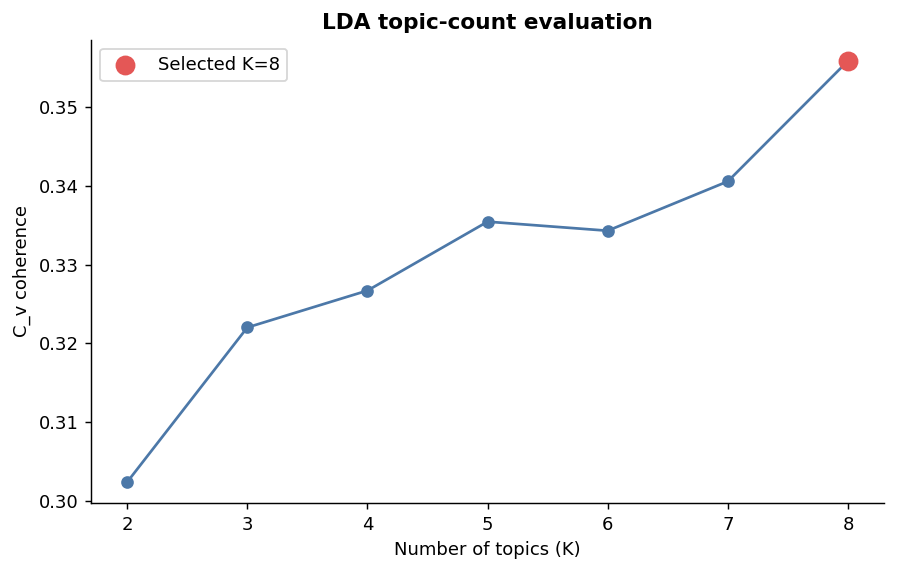

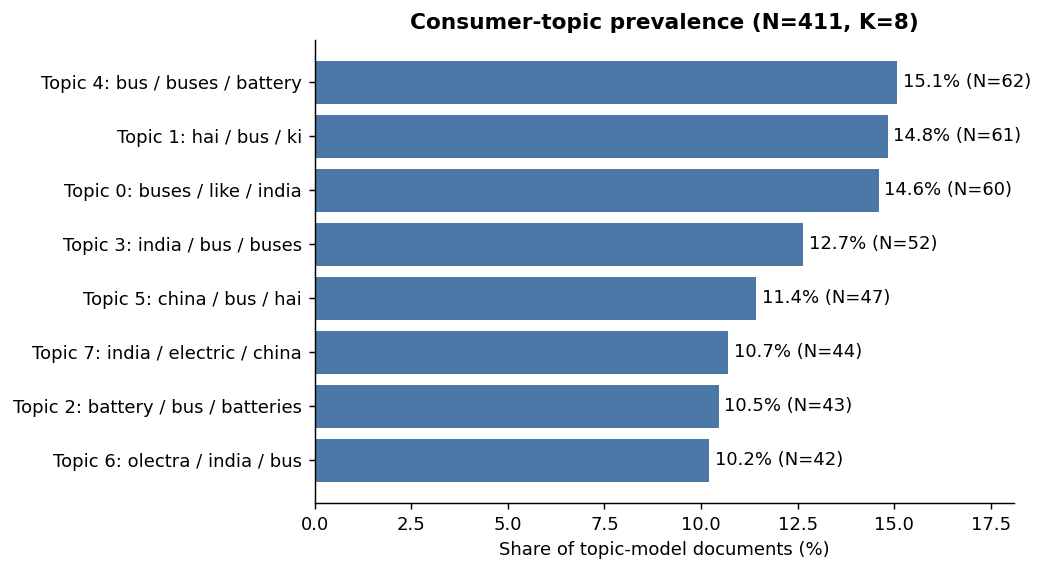

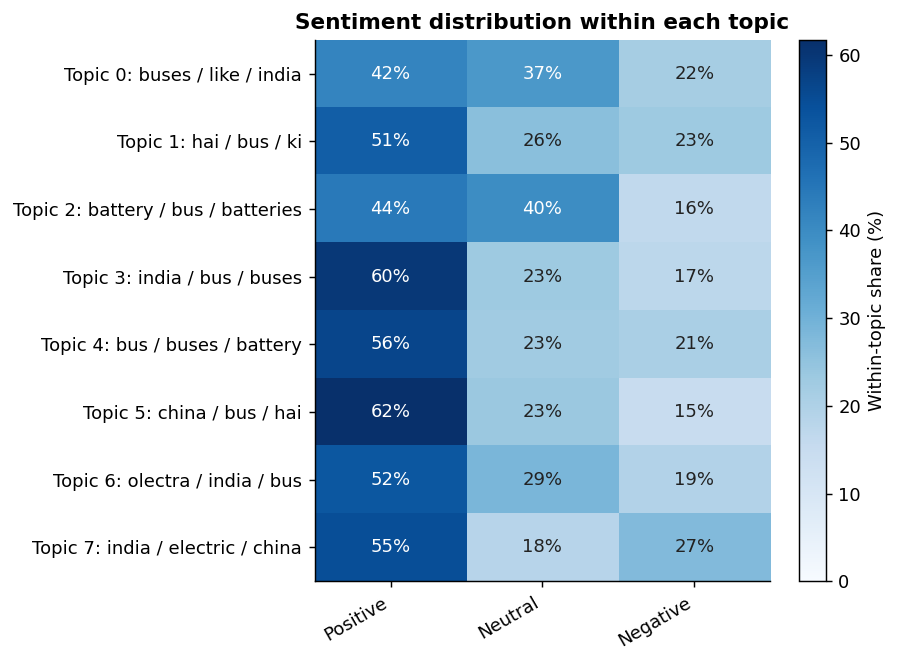

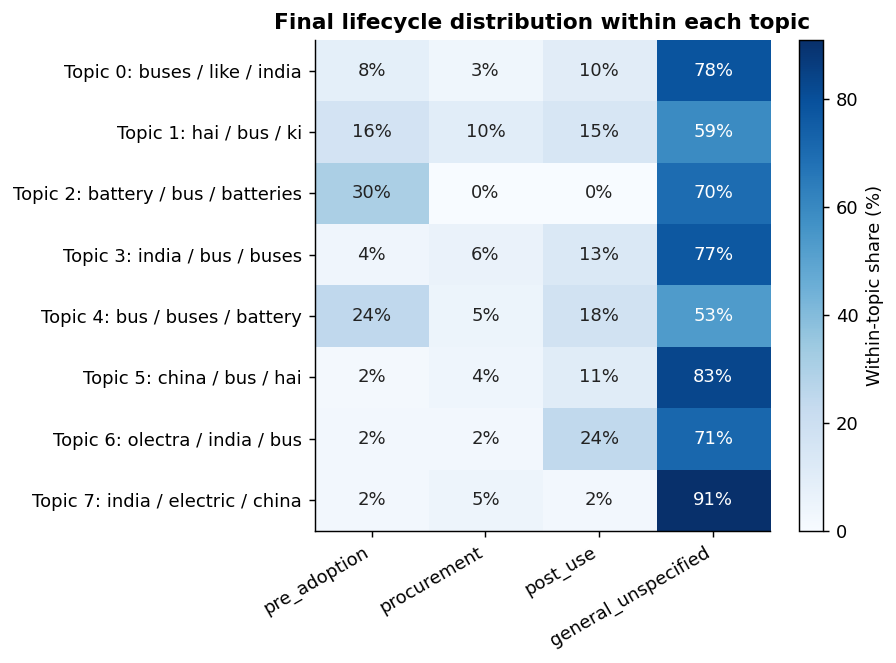

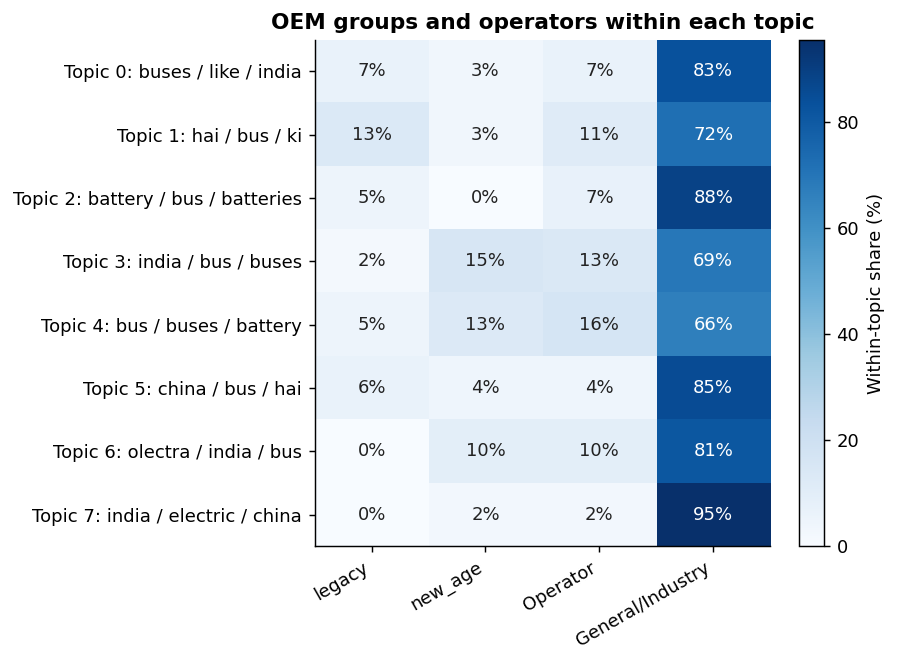

pyLDAvis: generated


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
fig,ax=plt.subplots(figsize=(7,4.5)); ax.plot(coherence_df.topic_count_k,coherence_df.coherence_cv,marker='o',color='#4C78A8'); sel=coherence_df[coherence_df.selected_model].iloc[0]
ax.scatter([sel.topic_count_k],[sel.coherence_cv],s=100,color='#E45756',zorder=3,label=f'Selected K={selected_k}'); ax.set_xticks(range(2,9)); ax.set_xlabel('Number of topics (K)'); ax.set_ylabel('C_v coherence'); ax.set_title('LDA topic-count evaluation'); ax.legend(); savefig('topic_coherence.png')

fig,ax=plt.subplots(figsize=(8,4.5)); z=topic_summary.sort_values('prevalence_pct'); bars=ax.barh(z.final_topic_label,z.prevalence_pct,color='#4C78A8'); ax.set_xlim(0,z.prevalence_pct.max()*1.2); ax.set_xlabel('Share of topic-model documents (%)'); ax.set_title(f'Consumer-topic prevalence (N={len(assigned)}, K={selected_k})'); ax.bar_label(bars,labels=[f'{p:.1f}% (N={n})' for p,n in zip(z.prevalence_pct,z.document_count)],padding=3); savefig('topic_prevalence.png')

def heatmap(table,dimension,order,title,name):
    x=table[table.dimension.eq(dimension)].pivot(index='dominant_topic_id',columns='group_value',values='percent').reindex(columns=order,fill_value=0).fillna(0)
    fig,ax=plt.subplots(figsize=(max(7,len(order)*1.25),max(4,selected_k*.65))); im=ax.imshow(x,cmap='Blues',vmin=0,vmax=max(1,x.to_numpy().max()),aspect='auto')
    ax.set_xticks(range(len(x.columns)),x.columns,rotation=30,ha='right'); ax.set_yticks(range(len(x.index)),[labels[int(i)] for i in x.index]); ax.set_title(title)
    for i in range(len(x.index)):
        for j in range(len(x.columns)): ax.text(j,i,f'{x.iloc[i,j]:.0f}%',ha='center',va='center',color='white' if x.iloc[i,j]>x.to_numpy().max()/2 else '#222')
    fig.colorbar(im,ax=ax,label='Within-topic share (%)'); savefig(name)

heatmap(topic_sent,'sentiment_label',SENTIMENT_ORDER,'Sentiment distribution within each topic','topic_sentiment_heatmap.png')
heatmap(topic_life,'lifecycle_stage_final',LIFECYCLE_ORDER,'Final lifecycle distribution within each topic','topic_lifecycle_heatmap.png')
heatmap(topic_oem,'analysis_group',['legacy','new_age','Operator','General/Industry'],'OEM groups and operators within each topic','topic_oem_group_heatmap.png')

pyldavis_status='generated'
try:
    import pyLDAvis, pyLDAvis.gensim_models
    vis=pyLDAvis.gensim_models.prepare(selected_model,corpus,dictionary,sort_topics=False)
    pyLDAvis.save_html(vis,str(FINAL_DIR/'pyldavis_consumer_topics.html'))
except Exception as exc:
    pyldavis_status=f'failed_non_blocking: {type(exc).__name__}: {exc}'
    (FINAL_DIR/'pyldavis_consumer_topics.html').write_text(f'<html><body><h1>pyLDAvis unavailable</h1><pre>{pyldavis_status}</pre></body></html>',encoding='utf-8')
print('pyLDAvis:',pyldavis_status)


## 13. Integrate topics, sentiment, and lifecycle

Subgroups below 10 rows are reported with an explicit weak-sample warning. Interpretations describe associations, not causality.


In [13]:
insights=[]
for tid,g in assigned.groupby('dominant_topic_id'):
    tid=int(tid); n=len(g); sc=g.sentiment_label.value_counts(); lc=g.lifecycle_stage_final.value_counts();
    oem_counts=g.loc[g.oem_group.isin(['legacy','new_age']),'oem_group'].value_counts(); entity_counts=g.entity_name_canonical.value_counts()
    dominant_group=(oem_counts.index[0] if len(oem_counts) else entity_counts.index[0])
    reptexts=reps.loc[reps.topic_id.eq(tid),'raw_text'].head(2).astype(str).str.replace('\n',' ',regex=False).tolist()
    dominant_life=lc.index[0]; neg_pct=100*sc.get('Negative',0)/n; pos_pct=100*sc.get('Positive',0)/n
    interpretation=f"This topic is most associated with {dominant_life} ({lc.iloc[0]}/{n}) and has {neg_pct:.1f}% negative versus {pos_pct:.1f}% positive comments."
    implication=("Review the recurring user friction represented by this topic before treating it as a market-wide problem." if neg_pct>pos_pct
                 else "Preserve the attributes associated with positive comments while validating them with larger, direct-source samples.")
    insights.append({'topic_id':tid,'final_topic_label':labels[tid],'document_count':n,'prevalence_pct':100*n/len(assigned),'dominant_lifecycle_stage':dominant_life,
      'positive_pct':pos_pct,'neutral_pct':100*sc.get('Neutral',0)/n,'negative_pct':neg_pct,'mean_sentiment_compound':g.vader_compound.mean(),
      'dominant_entity_or_oem_group':dominant_group,'representative_comment_1':reptexts[0] if reptexts else '',
      'representative_comment_2':reptexts[1] if len(reptexts)>1 else '','analytical_interpretation':interpretation,
      'preliminary_business_implication':implication,'small_sample_warning':'N<15; avoid strong interpretation' if n<15 else ''})
insights=pd.DataFrame(insights); insights.to_csv(FINAL_DIR/'topic_sentiment_lifecycle_insights.csv',index=False)

def subgroup_topics(mask,name):
    g=assigned.loc[mask]; counts=g.dominant_topic_id.value_counts().rename_axis('topic_id').reset_index(name='document_count')
    counts['subgroup_total_n']=len(g); counts['prevalence_within_subgroup_pct']=100*counts.document_count/len(g) if len(g) else np.nan
    counts['final_topic_label']=counts.topic_id.map(labels); counts['small_subgroup_warning']='N<10; avoid strong conclusion' if len(g)<10 else ''
    counts['subgroup']=name; return counts[['subgroup','subgroup_total_n','topic_id','final_topic_label','document_count','prevalence_within_subgroup_pct','small_subgroup_warning']]

negative_post=subgroup_topics(assigned.sentiment_label.eq('Negative')&assigned.lifecycle_stage_final.eq('post_use'),'negative_post_use')
negative_pre=subgroup_topics(assigned.sentiment_label.eq('Negative')&assigned.lifecycle_stage_final.eq('pre_adoption'),'negative_pre_adoption')
positive_exp=subgroup_topics(assigned.sentiment_label.eq('Positive')&assigned.lifecycle_stage_final.eq('post_use'),'positive_post_use_experience')
negative_post.to_csv(FINAL_DIR/'negative_post_use_topics.csv',index=False)
negative_pre.to_csv(FINAL_DIR/'negative_pre_adoption_topics.csv',index=False)
positive_exp.to_csv(FINAL_DIR/'positive_experience_topics.csv',index=False)

additional_subgroups=pd.concat([
 subgroup_topics(assigned.oem_group.eq('legacy'),'legacy_oems'),subgroup_topics(assigned.oem_group.eq('new_age'),'new_age_oems'),
 subgroup_topics(assigned.entity_name_canonical.eq('NueGo'),'nuego_operator_service')],ignore_index=True)
display(insights); display(negative_post); display(negative_pre); display(positive_exp); display(additional_subgroups)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,topic_id,final_topic_label,document_count,prevalence_pct,dominant_lifecycle_stage,positive_pct,neutral_pct,negative_pct,mean_sentiment_compound,dominant_entity_or_oem_group,representative_comment_1,representative_comment_2,analytical_interpretation,preliminary_business_implication,small_sample_warning
0,0,Topic 0: buses / like / india,60,14.598540,general_unspecified,41.666667,36.666667,21.666667,0.130485,legacy,"Countries like Singapore, Dubai, and many Euro...",Why do you raise suspecisions about what may h...,This topic is most associated with general_uns...,Preserve the attributes associated with positi...,
1,1,Topic 1: hai / bus / ki,61,14.841849,general_unspecified,50.819672,26.229508,22.950820,0.161939,legacy,"Ye sari companies (electra , jsw ) ko ban krna...",Indian govt should have started manufacturing ...,This topic is most associated with general_uns...,Preserve the attributes associated with positi...,
2,2,Topic 2: battery / bus / batteries,43,10.462287,general_unspecified,44.186047,39.534884,16.279070,0.142595,legacy,We should invest Battery swap technology for...,Electric buses are a pathetic investment. In m...,This topic is most associated with general_uns...,Preserve the attributes associated with positi...,
3,3,Topic 3: india / bus / buses,52,12.652068,general_unspecified,59.615385,23.076923,17.307692,0.202094,new_age,Excellent video. The money saved on capex of ...,India we still pay rs 5 for public transport a...,This topic is most associated with general_uns...,Preserve the attributes associated with positi...,
4,4,Topic 4: bus / buses / battery,62,15.085158,general_unspecified,56.451613,22.580645,20.967742,0.246402,new_age,Truth tata ashok leyland just assemble company...,Ind has always short cut and mindset of slaver...,This topic is most associated with general_uns...,Preserve the attributes associated with positi...,
5,5,Topic 5: china / bus / hai,47,11.435523,general_unspecified,61.702128,23.404255,14.893617,0.255128,legacy,NOBODY realises the operating costs of 1 Diese...,"Instead of freebies, even if 50% of freebie fu...",This topic is most associated with general_uns...,Preserve the attributes associated with positi...,
6,6,Topic 6: olectra / india / bus,42,10.218978,general_unspecified,52.380952,28.571429,19.047619,0.138221,new_age,Please double check the Non AC vs AC electric ...,"worst service ever, had to stand for 45 minute...",This topic is most associated with general_uns...,Preserve the attributes associated with positi...,
7,7,Topic 7: india / electric / china,44,10.705596,general_unspecified,54.545455,18.181818,27.272727,0.159416,new_age,Most of us think China has made us it's custom...,My experience with NueGo has been extremely di...,This topic is most associated with general_uns...,Preserve the attributes associated with positi...,


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,subgroup,subgroup_total_n,topic_id,final_topic_label,document_count,prevalence_within_subgroup_pct,small_subgroup_warning
0,negative_post_use,17,3,Topic 3: india / bus / buses,4,23.529412,
1,negative_post_use,17,4,Topic 4: bus / buses / battery,4,23.529412,
2,negative_post_use,17,6,Topic 6: olectra / india / bus,3,17.647059,
3,negative_post_use,17,1,Topic 1: hai / bus / ki,2,11.764706,
4,negative_post_use,17,0,Topic 0: buses / like / india,2,11.764706,
5,negative_post_use,17,5,Topic 5: china / bus / hai,1,5.882353,
6,negative_post_use,17,7,Topic 7: india / electric / china,1,5.882353,


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,subgroup,subgroup_total_n,topic_id,final_topic_label,document_count,prevalence_within_subgroup_pct,small_subgroup_warning
0,positive_post_use_experience,24,1,Topic 1: hai / bus / ki,6,25.000000,
1,positive_post_use_experience,24,6,Topic 6: olectra / india / bus,6,25.000000,
2,positive_post_use_experience,24,4,Topic 4: bus / buses / battery,5,20.833333,
3,positive_post_use_experience,24,5,Topic 5: china / bus / hai,3,12.500000,
4,positive_post_use_experience,24,0,Topic 0: buses / like / india,2,8.333333,
5,positive_post_use_experience,24,3,Topic 3: india / bus / buses,2,8.333333,


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,subgroup,subgroup_total_n,topic_id,final_topic_label,document_count,prevalence_within_subgroup_pct,small_subgroup_warning
0,legacy_oems,21,1,Topic 1: hai / bus / ki,8,38.095238,
1,legacy_oems,21,0,Topic 0: buses / like / india,4,19.047619,
2,legacy_oems,21,4,Topic 4: bus / buses / battery,3,14.285714,
3,legacy_oems,21,5,Topic 5: china / bus / hai,3,14.285714,
4,legacy_oems,21,2,Topic 2: battery / bus / batteries,2,9.523810,
5,legacy_oems,21,3,Topic 3: india / bus / buses,1,4.761905,
6,new_age_oems,27,3,Topic 3: india / bus / buses,8,29.629630,
7,new_age_oems,27,4,Topic 4: bus / buses / battery,8,29.629630,
8,new_age_oems,27,6,Topic 6: olectra / india / bus,4,14.814815,
9,new_age_oems,27,0,Topic 0: buses / like / india,2,7.407407,


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 14. Save the fully enriched 548-row dataset


In [14]:
df=df.merge(assignments,on='comment_id',how='left',validate='one_to_one')
df['provisional_topic_label']=df.dominant_topic_id.map(labels)
df['final_topic_label']=df.provisional_topic_label
df.to_csv(FINAL_DATA,index=False)
assert len(df)==548 and df.comment_id.is_unique and df.raw_text.equals(v1.raw_text)
assert df.loc[~sent_scope,score_cols+['sentiment_label']].isna().all().all()
assert df.loc[~df.comment_id.isin(assignments.comment_id),['dominant_topic_id','dominant_topic_probability']].isna().all().all()
print('Saved:',FINAL_DATA)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Saved: /content/drive/MyDrive/EV_Bus_Project/01_data/processed/ev_bus_text_analysis_final.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 15. Integrated final text-analysis report

The report follows the requested Finding → Evidence/metric → Interpretation → Business implication structure and clearly separates exploratory association from causal or definitive evidence.


In [15]:
def pctrow(table,key):
    z=table.iloc[0]; return f"N={int(z.eligible_n)}; Positive {z.positive_pct:.1f}%, Neutral {z.neutral_pct:.1f}%, Negative {z.negative_pct:.1f}%; mean compound {z.mean_compound:.3f}"

legacy=by_oem[by_oem.oem_group.eq('legacy')].iloc[0] if (by_oem.oem_group=='legacy').any() else None
newage=by_oem[by_oem.oem_group.eq('new_age')].iloc[0] if (by_oem.oem_group=='new_age').any() else None
topic_lines=[]
for _,r in topic_summary.iterrows(): topic_lines.append(f"- **{r.final_topic_label}** — {r.document_count} documents ({r.prevalence_pct:.1f}%); top terms: {r.top_12_terms}. Label requires team sign-off.")

report=f'''# Final Text Analysis Report

## 1. Executive summary

**Finding →** The frozen lifecycle layer combines 120 human-reviewed labels with conservatively handled automated labels. Consumer sentiment and topics are exploratory signals, not population estimates.
**Evidence/metric →** {pctrow(overall,'overall')}; topic model K={selected_k}, coherence={selected_coherence:.3f}.
**Interpretation →** The corpus surfaces recurring attitudes and themes, but mixed provenance and imbalance limit generalisation.
**Business implication →** Use results to prioritise questions for primary research and operational review, not as causal proof.

## 2. Business question

How do consumer attitudes, lifecycle context, and recurring discussion themes differ across EV-bus entities, OEM groupings, operators, platforms, and provenance categories?

## 3. Dataset and analytical scopes

- Master corpus: 548 rows, all retained.
- Consumer sentiment scope: {len(eligible)} audience-user rows with approved sentiment eligibility.
- Primary consumer-topic scope after usable-text and duplicate/role controls: {len(assigned)} rows.
- NueGo is an operator; Anthony Travels and NueGo are excluded from OEM comparisons.

## 4. Data-quality and provenance limitations

The corpus mixes direct YouTube/Instagram-derived material with AI-compiled secondary excerpts. It is heavily imbalanced by platform and entity, lacks complete URL/date metadata, and is not a random sample. Findings are exploratory associations. Media/research and creator/brand rows are excluded from consumer scopes.

## 5. Lifecycle-classification method and validation

**Finding →** Human review substantially corrected difficult low-confidence cases.
**Evidence/metric →** Risk-enriched round-1 agreement was 55.8% overall, 92.0% high, 94.1% medium, and 19.7% low; the main failure was `general_unspecified` under-classification.
**Interpretation →** High/medium automated labels were retained, while 41 unreviewed low-confidence rows were conservatively set to `general_unspecified`.
**Business implication →** Always use `lifecycle_label_source` to distinguish human-reviewed from automated evidence. Round 2 was generated but not manually completed due to the submission timeline.

## 6. Final lifecycle findings

{df_to_md(life_dist)}

Small lifecycle groups must not be strongly interpreted. Lifecycle labels describe comment context, not market-funnel conversion.

## 7. Sentiment methodology

VADER used `sentiment_text` only for consumer-sentiment-eligible rows. Positive is compound ≥0.05, Negative ≤-0.05, Neutral otherwise. VADER is exploratory and may misread Indian English, Hinglish, sarcasm, code-switching, implicit sentiment, and domain-specific meanings.

## 8. Overall sentiment findings

**Finding →** The eligible corpus has the descriptive sentiment mix shown below.
**Evidence/metric →** {pctrow(overall,'overall')}.
**Interpretation →** This is a lexicon-based distribution over eligible comments, not validated customer satisfaction.
**Business implication →** Use the manual sentiment-check sample before quoting fine-grained sentiment claims.

## 9. Lifecycle sentiment findings

{df_to_md(by_lifecycle)}

Stages with N<15 are flagged and should not be interpreted without an explicit small-sample caveat.

## 10. Legacy versus new-age findings

**Finding →** Descriptive sentiment differs between the two OEM groups.
**Evidence/metric →** Legacy: {('N='+str(int(legacy.eligible_n))+', mean compound '+format(legacy.mean_compound,'.3f')) if legacy is not None else 'no eligible rows'}; new-age: {('N='+str(int(newage.eligible_n))+', mean compound '+format(newage.mean_compound,'.3f')) if newage is not None else 'no eligible rows'}.
**Interpretation →** Small, imbalanced samples and entity composition can drive differences; no significance or causal claim is made.
**Business implication →** Treat this comparison as a hypothesis for balanced primary research, not a performance ranking.

## 11. Entity and operator findings

{df_to_md(by_entity)}

NueGo is reported separately as an operator. Tender performance, operator service, and OEM product quality are distinct constructs and must not be conflated.

## 12. Topic-model methodology

Gensim LDA used existing `topic_model_text`, consumer-topic eligibility, audience-user roles, usable texts of ≥3 tokens, duplicate-representative controls, frequent bigrams, dictionary filtering, and seed 42. K=2–8 was evaluated using coherence, log perplexity, top-term overlap, interpretability, and parsimony. K={selected_k} was selected with coherence {selected_coherence:.3f}; selection was not based on the numerical maximum alone. pyLDAvis status: `{pyldavis_status}`.

## 13. Final topics and representative comments

{chr(10).join(topic_lines)}

Labels remain provisional and require team sign-off. Representative comments are examples, not proof of prevalence beyond this sample.

## 14. Topic × sentiment × lifecycle findings

{df_to_md(insights)}

Negative post-use N={int(negative_post.subgroup_total_n.iloc[0]) if len(negative_post) else 0}; negative pre-adoption N={int(negative_pre.subgroup_total_n.iloc[0]) if len(negative_pre) else 0}; positive post-use N={int(positive_exp.subgroup_total_n.iloc[0]) if len(positive_exp) else 0}. Subgroups below 10 are explicitly weak samples.

## 15. Strategic implications

- **Finding →** Topics with more negative than positive comments identify candidate friction areas. **Evidence/metric →** See `topic_sentiment_lifecycle_insights.csv`. **Interpretation →** These are associations within an imbalanced corpus. **Business implication →** Validate through targeted interviews, service logs, and balanced surveys before intervention.
- **Finding →** Positive post-use topics identify attributes users may value. **Evidence/metric →** See `positive_experience_topics.csv`. **Interpretation →** VADER and topic labels remain provisional. **Business implication →** Test whether these attributes persist in verified direct-source feedback.
- **Finding →** OEM-group and NueGo topic mixes differ descriptively. **Evidence/metric →** See topic/OEM tables and subgroup counts. **Interpretation →** Entity, platform, and provenance composition confound comparison. **Business implication →** Keep operator service, OEM product quality, and tender outcomes separate in decisions.

## 16. Limitations

Mixed provenance, incomplete lineage, platform/entity imbalance, small subgroups, non-random sampling, automated lifecycle labels outside the reviewed set, VADER language limitations, provisional topic labels, and LDA instability restrict inference. Association is not causality. Exploratory evidence is not definitive evidence.

## 17. Files and charts generated

All CSV tables, six sentiment/lifecycle charts, five topic charts, pyLDAvis HTML, lifecycle freeze report, manual-check sample, lifecycle-frozen dataset, and the 548-row final analysis dataset are saved under `04_outputs/text/final`, `01_data/processed`, and `02_notebooks` within the project Drive folder.
'''
(FINAL_DIR/'final_text_analysis_report.md').write_text(report,encoding='utf-8')
print('Final report saved.')


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Final report saved.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 16. Final validation and terminal summary

This cell verifies protected inputs, analytical scopes, output existence, PNG integrity, row/ID/raw-text preservation, lifecycle policy, OEM/operator separation, and non-empty logical CSV outputs.


In [16]:
# Core row and lineage checks
life_check=pd.read_csv(LIFECYCLE_FROZEN); final_check=pd.read_csv(FINAL_DATA)
assert len(life_check)==548 and life_check.comment_id.is_unique
assert len(final_check)==548 and final_check.comment_id.is_unique
pd.testing.assert_series_equal(life_check.raw_text,v1.raw_text,check_names=False)
pd.testing.assert_series_equal(final_check.raw_text,v1.raw_text,check_names=False)
assert life_check.lifecycle_human_reviewed.astype(str).str.lower().eq('true').sum()==120
unreviewed_low=~life_check.lifecycle_human_reviewed.astype(str).str.lower().eq('true') & life_check.lifecycle_confidence.eq('low')
assert life_check.loc[unreviewed_low,'lifecycle_stage_final'].eq('general_unspecified').all()

# Scope checks
scope_check=as_bool(final_check.consumer_sentiment_eligible_final)
assert final_check.loc[scope_check,'vader_compound'].notna().all()
assert final_check.loc[~scope_check,'vader_compound'].isna().all()
topic_ids=set(assignments.comment_id)
assert topic_ids.issubset(set(final_check.loc[as_bool(final_check.consumer_topic_eligible_final),'comment_id']))
assert final_check.loc[final_check.comment_id.isin(topic_ids),'speaker_role_final'].eq('audience_user').all()
assert not final_check.loc[final_check.oem_group.isin(['legacy','new_age']),'entity_name_canonical'].isin(['NueGo','Anthony Travels']).any()
assert not final_check.loc[scope_check,'speaker_role_final'].isin(['media_or_research','creator_or_brand']).any()

required_csvs=['lifecycle_final_distribution.csv','lifecycle_label_source_distribution.csv','sentiment_overall.csv','sentiment_by_lifecycle.csv','sentiment_by_oem_group.csv',
'sentiment_by_entity.csv','sentiment_by_platform.csv','sentiment_by_provenance.csv','sentiment_manual_check_sample.csv','topic_coherence.csv','topic_model_summary.csv',
'topic_representative_comments.csv','topic_by_sentiment.csv','topic_by_lifecycle.csv','topic_by_oem_group.csv','document_topic_assignments.csv','topic_labels_for_review.csv',
'topic_sentiment_lifecycle_insights.csv','negative_post_use_topics.csv','negative_pre_adoption_topics.csv','positive_experience_topics.csv']
required_pngs=['sentiment_overall.png','sentiment_by_lifecycle_100pct.png','sentiment_legacy_vs_new_age.png','sentiment_by_entity.png','sentiment_by_platform.png',
'lifecycle_distribution_final.png','topic_coherence.png','topic_prevalence.png','topic_sentiment_heatmap.png','topic_lifecycle_heatmap.png','topic_oem_group_heatmap.png']
for name in required_csvs:
    p=FINAL_DIR/name; assert p.exists() and p.stat().st_size>0, p
for name in required_pngs:
    p=CHART_DIR/name; assert p.exists() and p.stat().st_size>1000 and p.read_bytes()[:8]==bytes.fromhex('89504e470d0a1a0a'), p
for p in [FINAL_DIR/'lifecycle_freeze_report.md',FINAL_DIR/'final_text_analysis_report.md',FINAL_DIR/'pyldavis_consumer_topics.html']:
    assert p.exists() and p.stat().st_size>0

hashes_after={str(p.relative_to(PROJECT_ROOT)):sha256(p) for p in [INPUT_V1,INPUT_REVIEW,FROZEN_INPUT]}
assert hashes_before==hashes_after

legacy_mean=float(legacy.mean_compound) if legacy is not None else float('nan'); newage_mean=float(newage.mean_compound) if newage is not None else float('nan')
print('FINAL VALIDATION PASSED')
print('Final lifecycle distribution:',life_dist.set_index('lifecycle_stage_final').row_count.to_dict())
print('Consumer sentiment N:',len(eligible))
print('Final sentiment distribution:',eligible.sentiment_label.value_counts().to_dict())
print(f'Legacy OEM N={int(legacy.eligible_n) if legacy is not None else 0}, mean compound={legacy_mean:.4f}')
print(f'New-age OEM N={int(newage.eligible_n) if newage is not None else 0}, mean compound={newage_mean:.4f}')
print(f'Selected K={selected_k}, coherence={selected_coherence:.4f}')
print('Final topic labels:',labels)
print('Negative post-use sample size:',int(negative_post.subgroup_total_n.iloc[0]) if len(negative_post) else 0)
print('Lifecycle frozen:',LIFECYCLE_FROZEN)
print('Final dataset:',FINAL_DATA)
print('Final outputs:',FINAL_DIR)
print('Charts:',CHART_DIR)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

FINAL VALIDATION PASSED
Final lifecycle distribution: {'pre_adoption': 53, 'procurement': 20, 'post_use': 74, 'general_unspecified': 401}
Consumer sentiment N: 438
Final sentiment distribution: {'Positive': 225, 'Neutral': 128, 'Negative': 85}
Legacy OEM N=21, mean compound=0.3593
New-age OEM N=27, mean compound=0.2643
Selected K=8, coherence=0.3558
Final topic labels: {0: 'Topic 0: buses / like / india', 1: 'Topic 1: hai / bus / ki', 2: 'Topic 2: battery / bus / batteries', 3: 'Topic 3: india / bus / buses', 4: 'Topic 4: bus / buses / battery', 5: 'Topic 5: china / bus / hai', 6: 'Topic 6: olectra / india / bus', 7: 'Topic 7: india / electric / china'}
Negative post-use sample size: 17
Lifecycle frozen: /content/drive/MyDrive/EV_Bus_Project/01_data/processed/ev_bus_text_corpus_lifecycle_frozen.csv
Final dataset: /content/drive/MyDrive/EV_Bus_Project/01_data/processed/ev_bus_text_analysis_final.csv
Final outputs: /content/drive/MyDrive/EV_Bus_Project/04_outputs/text/final
Charts: /cont

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [17]:
from pathlib import Path
import pandas as pd
import shutil
from datetime import datetime

PROJECT_ROOT = Path("/content/drive/MyDrive/EV_Bus_Project")
FINAL_DIR = PROJECT_ROOT / "04_outputs" / "text" / "final"
PROCESSED_DIR = PROJECT_ROOT / "01_data" / "processed"

# Final human-interpreted topic labels
LABEL_MAP = {
    0: "Public Transport Economics & Government Operating Models",
    1: "Indian EV-Bus Adoption: R&D, Operations & User Experience",
    2: "Battery Technology, Swapping & Lifecycle Economics",
    3: "Public Infrastructure, Funding & Alternative Transit",
    4: "Domestic Manufacturing, R&D & China Dependence",
    5: "Tender Economics, Public Funding & Private Operators",
    6: "New-Age OEM Execution, Reliability & Service Risk",
    7: "Supply-Chain Risk, Charging Alternatives & Service Gaps",
}

OLD_LABELS = {
    0: "Topic 0: buses / like / india",
    1: "Topic 1: hai / bus / ki",
    2: "Topic 2: battery / bus / batteries",
    3: "Topic 3: india / bus / buses",
    4: "Topic 4: bus / buses / battery",
    5: "Topic 5: china / bus / hai",
    6: "Topic 6: olectra / india / bus",
    7: "Topic 7: india / electric / china",
}

# Create backup folder before modifying anything
BACKUP_DIR = (
    FINAL_DIR
    / f"backup_before_topic_label_update_{datetime.now():%Y%m%d_%H%M%S}"
)
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

def backup_file(path):
    if path.exists():
        shutil.copy2(path, BACKUP_DIR / path.name)

updated_files = []

# Update all final CSV files containing topic IDs
for csv_path in FINAL_DIR.glob("*.csv"):
    df = pd.read_csv(csv_path)

    topic_id_column = None

    if "topic_id" in df.columns:
        topic_id_column = "topic_id"
    elif "dominant_topic_id" in df.columns:
        topic_id_column = "dominant_topic_id"

    if topic_id_column is None:
        continue

    topic_ids = pd.to_numeric(df[topic_id_column], errors="coerce")
    approved_labels = topic_ids.map(LABEL_MAP)

    if approved_labels.notna().any():
        backup_file(csv_path)

        # Preserve provisional labels, but update/create final labels
        if "final_topic_label" not in df.columns:
            df["final_topic_label"] = approved_labels
        else:
            df.loc[approved_labels.notna(), "final_topic_label"] = (
                approved_labels[approved_labels.notna()]
            )

        # Special approval fields in topic_labels_for_review.csv
        if csv_path.name == "topic_labels_for_review.csv":
            df["team_approved_label"] = approved_labels
            df["team_signoff_status"] = "APPROVED_BY_TEAM"
            df["team_review_note"] = (
                "Human-interpreted using top terms and representative comments; "
                "topics overlap because coherence is moderate."
            )

        df.to_csv(csv_path, index=False, encoding="utf-8")
        updated_files.append(csv_path.name)

# Update final enriched dataset
analysis_dataset = PROCESSED_DIR / "ev_bus_text_analysis_final.csv"

if analysis_dataset.exists():
    backup_file(analysis_dataset)

    analysis_df = pd.read_csv(analysis_dataset)
    dominant_ids = pd.to_numeric(
        analysis_df["dominant_topic_id"], errors="coerce"
    )
    approved_labels = dominant_ids.map(LABEL_MAP)

    analysis_df.loc[
        approved_labels.notna(), "final_topic_label"
    ] = approved_labels[approved_labels.notna()]

    analysis_df.to_csv(
        analysis_dataset,
        index=False,
        encoding="utf-8",
    )

    updated_files.append(analysis_dataset.name)

# Update topic names inside the Markdown report
report_path = FINAL_DIR / "final_text_analysis_report.md"

if report_path.exists():
    backup_file(report_path)

    report_text = report_path.read_text(encoding="utf-8")

    for topic_id, old_label in OLD_LABELS.items():
        report_text = report_text.replace(
            old_label,
            LABEL_MAP[topic_id],
        )

    # Add a topic-interpretation caveat if it is not already present
    caveat = """
> **Topic interpretation note:** Topic labels were assigned through human
> review of top terms and representative comments. The selected eight-topic
> model has moderate coherence, so topics should be treated as overlapping
> exploratory themes rather than mutually exclusive consumer segments.
"""

    if "Topic interpretation note" not in report_text:
        report_text += "\n\n" + caveat

    report_path.write_text(report_text, encoding="utf-8")
    updated_files.append(report_path.name)

# Save a separate approved topic dictionary
topic_dictionary = pd.DataFrame(
    [
        {
            "topic_id": topic_id,
            "final_topic_label": label,
            "approval_status": "APPROVED_BY_TEAM",
        }
        for topic_id, label in LABEL_MAP.items()
    ]
)

topic_dictionary.to_csv(
    FINAL_DIR / "approved_topic_labels.csv",
    index=False,
    encoding="utf-8",
)

print("TOPIC LABEL UPDATE COMPLETED")
print("Backup folder:", BACKUP_DIR)
print("\nUpdated files:")
for file_name in updated_files:
    print("-", file_name)

print("\nApproved labels:")
for topic_id, label in LABEL_MAP.items():
    print(f"Topic {topic_id}: {label}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

TOPIC LABEL UPDATE COMPLETED
Backup folder: /content/drive/MyDrive/EV_Bus_Project/04_outputs/text/final/backup_before_topic_label_update_20260717_112417

Updated files:
- topic_representative_comments.csv
- topic_model_summary.csv
- topic_by_sentiment.csv
- topic_by_lifecycle.csv
- topic_by_oem_group.csv
- document_topic_assignments.csv
- topic_labels_for_review.csv
- topic_sentiment_lifecycle_insights.csv
- negative_post_use_topics.csv
- negative_pre_adoption_topics.csv
- positive_experience_topics.csv
- ev_bus_text_analysis_final.csv
- final_text_analysis_report.md

Approved labels:
Topic 0: Public Transport Economics & Government Operating Models
Topic 1: Indian EV-Bus Adoption: R&D, Operations & User Experience
Topic 2: Battery Technology, Swapping & Lifecycle Economics
Topic 3: Public Infrastructure, Funding & Alternative Transit
Topic 4: Domestic Manufacturing, R&D & China Dependence
Topic 5: Tender Economics, Public Funding & Private Operators
Topic 6: New-Age OEM Execution, Rel

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [18]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("/content/drive/MyDrive/EV_Bus_Project")
REPORT_DIR = PROJECT_ROOT / "05_report"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

evidence_rows = [
    {
        "Evidence_ID": "E01",
        "Modality": "Market/Tender",
        "Finding": "New-age players dominated the cited 10,900-bus PM E-DRIVE tender.",
        "Metric": (
            "PMI: 5,210; EKA: 3,485; Olectra: 1,785; "
            "Anthony Travels consortium: 420. Tata, JBM and VECV: 0."
        ),
        "Interpretation": (
            "The challengers demonstrated stronger commercial competitiveness "
            "in this tender round."
        ),
        "Business_Implication": (
            "Legacy OEMs cannot rely only on engineering reputation or service depth."
        ),
        "Recommended_Action": (
            "Create selective, route-level GCC bidding models with financing "
            "and operating partners."
        ),
        "Source_File": (
            "ev_bus_tenders_CORRECTED.csv; "
            "EV_Bus_Tender_Competitor_User_Analysis.docx"
        ),
        "Evidence_Strength": "Strong tender evidence; verify latest contract status",
        "Report_Section": "Market disruption",
        "Suggested_Slide": "Tender disruption",
    },
    {
        "Evidence_ID": "E02",
        "Modality": "Market/Tender",
        "Finding": "Tender success is not the same as product superiority.",
        "Metric": (
            "GCC bids combine financing, ₹/km pricing, charging, operations, "
            "maintenance, availability and payment risk."
        ),
        "Interpretation": (
            "Tender allocation primarily measures commercial structure and "
            "risk appetite after technical qualification."
        ),
        "Business_Implication": (
            "The OEM strategy must optimise lifetime contract economics, not "
            "merely bus specifications."
        ),
        "Recommended_Action": (
            "Develop a total-cost and risk-pricing engine for every tender."
        ),
        "Source_File": "EV_Bus_Tender_Competitor_User_Analysis.docx",
        "Evidence_Strength": "Strong strategic interpretation",
        "Report_Section": "Tender model",
        "Suggested_Slide": "What GCC really tests",
    },
    {
        "Evidence_ID": "E03",
        "Modality": "Competitor Research",
        "Finding": (
            "Legacy OEMs retain advantages in service networks, spares, "
            "operating proof and institutional trust."
        ),
        "Metric": (
            "Tata is the working benchmark for publicly visible operating proof; "
            "legacy OEMs have broader commercial-vehicle support ecosystems."
        ),
        "Interpretation": (
            "New-age tender success has not eliminated the value of reliability "
            "and lifetime support."
        ),
        "Business_Implication": (
            "Trust and uptime can become a commercial differentiator rather "
            "than merely a brand claim."
        ),
        "Recommended_Action": (
            "Bundle uptime guarantees, repair-TAT SLAs and depot-parts availability "
            "into the GCC proposition."
        ),
        "Source_File": "EV_Bus_Tender_Competitor_User_Analysis.docx",
        "Evidence_Strength": "Working public evidence; final citations required",
        "Report_Section": "Competitive advantage",
        "Suggested_Slide": "Tender wins versus operating proof",
    },
    {
        "Evidence_ID": "E04",
        "Modality": "Text/Sentiment",
        "Finding": "Overall EV-bus consumer discourse is more positive than negative.",
        "Metric": (
            "N=438; Positive 51.4%; Neutral 29.2%; Negative 19.4%; "
            "mean VADER compound 0.179."
        ),
        "Interpretation": (
            "The market is not broadly resistant to EV buses, but aggregate "
            "positivity hides lifecycle-specific problems."
        ),
        "Business_Implication": (
            "Communication should build on existing acceptance while addressing "
            "concrete operational concerns."
        ),
        "Recommended_Action": (
            "Avoid generic EV education alone; add proof of reliability, comfort "
            "and service performance."
        ),
        "Source_File": "sentiment_overall.csv",
        "Evidence_Strength": "Exploratory; VADER and mixed-provenance limitations",
        "Report_Section": "Text analytics",
        "Suggested_Slide": "Overall sentiment",
    },
    {
        "Evidence_ID": "E05",
        "Modality": "Text/Lifecycle",
        "Finding": "Negative sentiment increases materially after actual use.",
        "Metric": (
            "Post-use negative: 34.7% (17/49); "
            "Pre-adoption negative: 22.9% (11/48)."
        ),
        "Interpretation": (
            "The largest perception gap emerges during operational delivery, "
            "not only before adoption."
        ),
        "Business_Implication": (
            "Execution quality, service recovery and uptime are central to "
            "long-term EV-bus adoption."
        ),
        "Recommended_Action": (
            "Prioritise predictive maintenance, AC uptime, route reliability, "
            "refund resolution and customer support."
        ),
        "Source_File": "sentiment_by_lifecycle.csv",
        "Evidence_Strength": "Directionally useful; lifecycle labels partly automated",
        "Report_Section": "Lifecycle sentiment",
        "Suggested_Slide": "Expectation-to-experience gap",
    },
    {
        "Evidence_ID": "E06",
        "Modality": "Methodology",
        "Finding": "Lifecycle classification is reliable at high and medium confidence.",
        "Metric": (
            "High-confidence agreement: 92.0%; medium: 94.1%; "
            "low: 19.7% in a risk-enriched 120-row review."
        ),
        "Interpretation": (
            "The main failure was conservative under-classification into "
            "general/unspecified."
        ),
        "Business_Implication": (
            "Specific lifecycle findings should rely on reviewed or higher-confidence labels."
        ),
        "Recommended_Action": (
            "Retain low-confidence unreviewed rows as general/unspecified."
        ),
        "Source_File": "lifecycle_validation_round1_report.md",
        "Evidence_Strength": "Validated, but sample intentionally risk-enriched",
        "Report_Section": "Methodological rigor",
        "Suggested_Slide": "Validation",
    },
    {
        "Evidence_ID": "E07",
        "Modality": "Text/OEM Comparison",
        "Finding": (
            "Legacy OEM discussion is more positive than new-age OEM discussion "
            "in the available sample."
        ),
        "Metric": (
            "Legacy: N=21, mean compound 0.359, negative 9.5%; "
            "New-age: N=27, mean 0.264, negative 14.8%."
        ),
        "Interpretation": (
            "The sample suggests a possible legacy trust advantage, but it does "
            "not prove superior product performance."
        ),
        "Business_Implication": (
            "Legacy OEMs should translate trust into measurable uptime and "
            "contract-delivery guarantees."
        ),
        "Recommended_Action": (
            "Use reliability evidence in tenders and communication, while avoiding "
            "unsupported superiority claims."
        ),
        "Source_File": "sentiment_by_oem_group.csv",
        "Evidence_Strength": "Exploratory; small OEM samples",
        "Report_Section": "OEM perception",
        "Suggested_Slide": "Trust signal",
    },
    {
        "Evidence_ID": "E08",
        "Modality": "Text/Operator",
        "Finding": "Operator-service complaints are a major source of negative experience.",
        "Metric": (
            "NueGo: N=38; negative 36.8%; mean compound 0.068."
        ),
        "Interpretation": (
            "Passenger dissatisfaction often reflects booking, pickup, refunds, "
            "staff behaviour and customer support—not necessarily bus manufacturing."
        ),
        "Business_Implication": (
            "OEM, operator and passenger-service accountability must be separated."
        ),
        "Recommended_Action": (
            "Introduce joint OEM–operator service dashboards and escalation SLAs."
        ),
        "Source_File": "sentiment_by_entity.csv",
        "Evidence_Strength": "Useful operator evidence; not an OEM-quality measure",
        "Report_Section": "Operator experience",
        "Suggested_Slide": "Who owns the experience?",
    },
    {
        "Evidence_ID": "E09",
        "Modality": "Text/Topic Model",
        "Finding": (
            "Battery technology, swapping and lifecycle economics form a distinct "
            "consumer discussion theme."
        ),
        "Metric": (
            "Topic 2 prevalence: 10.5%; mean sentiment 0.143; negative 16.3%."
        ),
        "Interpretation": (
            "Consumers discuss chemistry, degradation, replacement cost, swapping "
            "and alternative fuels—not just headline range."
        ),
        "Business_Implication": (
            "Battery-risk communication and contract design need greater specificity."
        ),
        "Recommended_Action": (
            "Communicate warranties, degradation assumptions, replacement ownership "
            "and end-of-life plans."
        ),
        "Source_File": "topic_model_summary.csv",
        "Evidence_Strength": "Exploratory LDA topic; moderate coherence",
        "Report_Section": "Consumer themes",
        "Suggested_Slide": "Battery-risk debate",
    },
    {
        "Evidence_ID": "E10",
        "Modality": "Text/Topic Model",
        "Finding": (
            "Domestic manufacturing, R&D and dependence on Chinese components "
            "form the largest discovered topic."
        ),
        "Metric": (
            "Topic 4 prevalence: 15.1%; positive 56.5%; negative 21.0%."
        ),
        "Interpretation": (
            "Localisation is simultaneously a source of optimism and geopolitical concern."
        ),
        "Business_Implication": (
            "A credible localisation roadmap may strengthen both institutional "
            "and consumer trust."
        ),
        "Recommended_Action": (
            "Disclose localisation milestones, battery sourcing and domestic "
            "engineering ownership."
        ),
        "Source_File": "topic_model_summary.csv",
        "Evidence_Strength": "Exploratory; topic overlaps with other themes",
        "Report_Section": "Supply-chain perception",
        "Suggested_Slide": "Make-in-India credibility",
    },
    {
        "Evidence_ID": "E11",
        "Modality": "Text/Topic Model",
        "Finding": (
            "New-age OEM execution, reliability and service risk is a recurring theme."
        ),
        "Metric": (
            "Topic 6 prevalence: 10.2%; negative 19.0%; "
            "new-age OEMs are the dominant OEM group."
        ),
        "Interpretation": (
            "Tender-winning scale creates questions about fleet uptime, delivery, "
            "battery replacement and service expansion."
        ),
        "Business_Implication": (
            "Scaling the order book without scaling service capability could damage trust."
        ),
        "Recommended_Action": (
            "Tie tender growth to depot readiness, technician capacity, parts fill "
            "rates and phased deployment gates."
        ),
        "Source_File": "topic_sentiment_lifecycle_insights.csv",
        "Evidence_Strength": "Exploratory association, not causal proof",
        "Report_Section": "Execution risk",
        "Suggested_Slide": "Can challengers deliver at scale?",
    },
    {
        "Evidence_ID": "E12",
        "Modality": "Data Limitation",
        "Finding": "The text corpus is exploratory rather than representative.",
        "Metric": (
            "548 retained rows; YouTube dominates the source mix; "
            "OEM-specific samples are small; URL/date coverage is incomplete."
        ),
        "Interpretation": (
            "Percentages should be treated as directional signals, not market-wide estimates."
        ),
        "Business_Implication": (
            "Final strategic recommendations should triangulate text evidence with "
            "image, video, tender and operational data."
        ),
        "Recommended_Action": (
            "Use RAG to expose source context and clearly tag evidence confidence."
        ),
        "Source_File": "preprocessing_report.md",
        "Evidence_Strength": "Known limitation",
        "Report_Section": "Limitations",
        "Suggested_Slide": "Methodology and caveats",
    },
]

evidence_df = pd.DataFrame(evidence_rows)

csv_path = REPORT_DIR / "MASTER_EVIDENCE_MATRIX.csv"
xlsx_path = REPORT_DIR / "MASTER_EVIDENCE_MATRIX.xlsx"

evidence_df.to_csv(csv_path, index=False, encoding="utf-8")

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    evidence_df.to_excel(
        writer,
        sheet_name="Evidence Matrix",
        index=False,
    )

    worksheet = writer.sheets["Evidence Matrix"]
    worksheet.freeze_panes = "A2"
    worksheet.auto_filter.ref = worksheet.dimensions

    widths = {
        "A": 12,
        "B": 22,
        "C": 45,
        "D": 45,
        "E": 45,
        "F": 45,
        "G": 45,
        "H": 40,
        "I": 38,
        "J": 25,
        "K": 25,
    }

    for column, width in widths.items():
        worksheet.column_dimensions[column].width = width

    for row in worksheet.iter_rows():
        for cell in row:
            cell.alignment = cell.alignment.copy(
                wrap_text=True,
                vertical="top",
            )

storyline = """# Strategic Storyline: Indian EV-Bus Market Disruption

## Central boardroom question

How should a legacy Indian automotive OEM respond when new-age EV-bus
companies are winning large GCC tenders, while legacy players retain stronger
service infrastructure, operating proof and public trust?

## One-line conclusion

The winning strategy is not to choose between aggressive tender economics and
reliable execution. It is to build a **trust-backed GCC model** that combines
competitive lifetime pricing with measurable uptime, service and battery-risk
guarantees.

## Storyline

### 1. The market has shifted from selling buses to operating mobility systems

Under the GCC model, the bidder must finance, deploy, charge, operate and
maintain buses over long contract periods. Tender success therefore depends on
commercial structure and risk appetite, not only engineering specifications.

### 2. New-age OEMs are winning the procurement battle

PMI, EKA and Olectra captured the OEM-linked allocations in the cited
10,900-bus tender round. Their advantages include aggressive per-kilometre
pricing, dedicated operating structures and EV-focused capital deployment.

### 3. Tender wins do not yet prove superior lifetime performance

The strongest unresolved question is whether the challengers can convert large
order books into reliable, financially sustainable and passenger-friendly
operations at scale.

### 4. Consumer sentiment is positive overall, but weakens after actual use

Overall sentiment is 51.4% positive and 19.4% negative. Negative sentiment rises
to 34.7% in post-use comments, compared with 22.9% in pre-adoption comments.

This indicates an expectation-to-experience gap.

### 5. The experience problem is broader than the bus itself

Post-use dissatisfaction includes delays, refunds, pickup failures, AC and
comfort issues, maintenance concerns and customer-support failures.

NueGo is an operator, not an OEM. Operator-service complaints must not be
treated automatically as manufacturing-quality failures.

### 6. Legacy trust remains strategically valuable

The available OEM sample shows higher sentiment for legacy OEMs than new-age
OEMs, although the sample is small. Public research also indicates stronger
service depth and operating proof among established OEMs.

The opportunity is to turn trust into a measurable commercial offer.

### 7. Battery and localisation concerns shape adoption

Consumer topics repeatedly discuss battery degradation, replacement economics,
swapping, charging infrastructure, Chinese component dependence and domestic
R&D.

Battery risk must therefore be addressed in both product architecture and
communication.

## Recommended strategic position

**Trust-backed GCC growth**

Compete selectively on lifetime ₹/km economics while differentiating through:

1. Uptime and route-availability guarantees
2. Repair turnaround and depot-parts SLAs
3. Transparent battery warranty and replacement ownership
4. Financing and infrastructure partnerships
5. Evidence-led passenger and operator communication

## Three-year strategy skeleton

### Year 1 — Prove

- Select two or three route archetypes for GCC pilots
- Establish route-level lifetime-cost and risk models
- Publish uptime, charging downtime and repair-TAT dashboards
- Create depot readiness and service-capacity gates
- Test reliability-led communication

### Year 2 — Scale

- Expand project SPVs and infrastructure-finance partnerships
- Build regional depot-parts and technician hubs
- Introduce battery-health monitoring and predictive maintenance
- Standardise operator escalation and passenger service SLAs
- Scale only where operating KPIs meet thresholds

### Year 3 — Lead

- Position the OEM as an integrated EV public-mobility platform
- Offer modular financing, charging, maintenance and analytics packages
- Create a national reliability and battery-health benchmark
- Extend capabilities to intercity and institutional electric mobility

## KPIs to track

- Fleet uptime
- Breakdown rate per 10,000 km
- Mean time to repair
- Trip cancellation rate
- Charging downtime
- Energy consumed per kilometre
- Parts fill rate
- Customer complaint resolution time
- Operator payment delays
- Actual versus contracted kilometres
- Passenger comfort and satisfaction

## What image analytics must add

- Which visual features communicate trust, comfort and modernity?
- Do official images overemphasise futuristic design and under-show operations?
- Are passengers, drivers, accessibility and charging infrastructure visible?

## What video analytics must add

- Which narrative formats produce higher engagement?
- Does human storytelling outperform specification-heavy communication?
- What duration, pacing and opening structure work best?

## What the multimodal RAG must add

The RAG system should allow an executive to ask:

- Why are new-age OEMs winning tenders?
- What are the main post-use pain points?
- Which risks arise from battery and supply-chain dependence?
- Which visual and video elements communicate reliability?
- What should the OEM prioritise over the next three years?

## Required caveats

- Tender allocation is not a direct product-quality ranking.
- Text sentiment is exploratory and based on an imbalanced corpus.
- OEM-specific sentiment samples are small.
- VADER may misread Indian English, Hinglish and sarcasm.
- Topic labels are qualitative interpretations of an overlapping LDA model.
- Operator complaints must be separated from OEM manufacturing performance.
- Final market claims require verified source citations.
"""

storyline_path = REPORT_DIR / "STRATEGIC_STORYLINE.md"
storyline_path.write_text(storyline, encoding="utf-8")

print("EVIDENCE MATRIX AND STORYLINE CREATED")
print("CSV:", csv_path)
print("Excel:", xlsx_path)
print("Storyline:", storyline_path)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

EVIDENCE MATRIX AND STORYLINE CREATED
CSV: /content/drive/MyDrive/EV_Bus_Project/05_report/MASTER_EVIDENCE_MATRIX.csv
Excel: /content/drive/MyDrive/EV_Bus_Project/05_report/MASTER_EVIDENCE_MATRIX.xlsx
Storyline: /content/drive/MyDrive/EV_Bus_Project/05_report/STRATEGIC_STORYLINE.md


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [19]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/EV_Bus_Project")
REPORT_PATH = (
    PROJECT_ROOT
    / "04_outputs"
    / "text"
    / "final"
    / "final_text_analysis_report.md"
)

report_text = REPORT_PATH.read_text(encoding="utf-8")

report_text = report_text.replace(
    "Label requires team sign-off.",
    (
        "Label approved through human interpretation of the top terms "
        "and representative comments."
    ),
)

report_text = report_text.replace(
    (
        "Labels remain provisional and require team sign-off. "
        "Representative comments are examples, not proof of prevalence "
        "beyond this sample."
    ),
    (
        "Topic labels were approved through human interpretation of the "
        "top terms and representative comments. Because model coherence "
        "is moderate, the topics remain overlapping exploratory themes. "
        "Representative comments are examples, not proof of prevalence "
        "beyond this sample."
    ),
)

report_text = report_text.replace(
    "VADER and topic labels remain provisional.",
    (
        "VADER remains exploratory, while topic labels are "
        "human-interpreted descriptions of the LDA outputs."
    ),
)

REPORT_PATH.write_text(report_text, encoding="utf-8")

print("FINAL REPORT WORDING UPDATED")
print("Saved to:", REPORT_PATH)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

FINAL REPORT WORDING UPDATED
Saved to: /content/drive/MyDrive/EV_Bus_Project/04_outputs/text/final/final_text_analysis_report.md


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Colab execution checklist

1. Run the pinned installation cell.
2. Restart the Colab runtime immediately.
3. Run the Drive-mount/path cell and confirm the three authoritative inputs exist.
4. Run the approved NLTK-download cell.
5. Run environment checks.
6. Run all remaining cells sequentially through final validation.
7. Confirm the last cell prints `FINAL VALIDATION PASSED` and that outputs appear in Google Drive.
